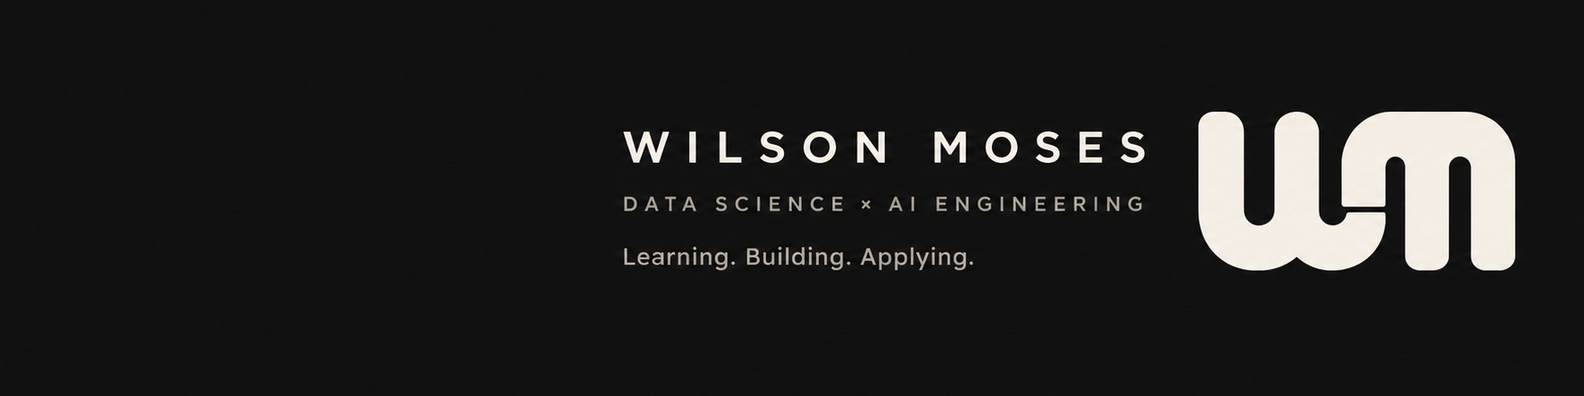

# Loan Approval Prediction

## Week 3: Advanced Data Exploration, Statistical Analysis and Feature Engineering

### Project Objective

The objective of this project is to investigate the factors associated with
loan approval decisions through advanced exploratory data analysis,
statistical hypothesis testing and feature engineering.

The analysis builds upon the cleaned dataset produced during Week 2 and
aims to create a reliable machine-learning-ready dataset for predictive
modelling in Week 4.

### Business Problem

Financial institutions must evaluate loan applications while balancing
customer accessibility with credit risk. Understanding the characteristics
associated with loan approval can support consistent decision-making,
improve risk assessment and guide the development of predictive models.

### Target Variable

The target variable is `loan_status`:

- `Y`: Loan approved
- `N`: Loan rejected

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

OUTPUT_DIR = Path("week3_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42


## Load the Cleaned Dataset

In [2]:
candidate_paths = [
    Path("loan_prediction_cleaned.csv"),
    Path("data/loan_prediction_cleaned.csv"),
    Path("../data/loan_prediction_cleaned.csv"),
    Path("upload/loan_prediction_cleaned.csv"),
]

file_path = next((path for path in candidate_paths if path.exists()), None)
if file_path is None:
    raise FileNotFoundError(
        "Place loan_prediction_cleaned.csv beside the notebook or inside a data folder."
    )

df = pd.read_csv(file_path)
print(f"Dataset loaded from: {file_path.resolve()}")
display(df.head())


Dataset loaded from: /workspace/scratch/4b61e7e42614/upload/loan_prediction_cleaned.csv
  gender married dependents     education self_employed  applicant_income  \
0   Male      No          0      Graduate            No              5849   
1   Male     Yes          1      Graduate            No              4583   
2   Male     Yes          0      Graduate           Yes              3000   
3   Male     Yes          0  Not Graduate            No              2583   
4   Male      No          0      Graduate            No              6000   

   coapplicant_income  loan_amount  loan_amount_term  credit_history  \
0               0.000      128.000           360.000           1.000   
1           1,508.000      128.000           360.000           1.000   
2               0.000       66.000           360.000           1.000   
3           2,358.000      120.000           360.000           1.000   
4               0.000      141.000           360.000           1.000   

  property_area 

### Check the Dimensions

In [3]:
print(f"Number of observations: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")

Number of observations: 614
Number of variables: 14


### Create a working copy

In [4]:
loan_df = df.copy()

The original loaded dataset remains unchanged while we investigate and engineer new variables.

### Examine Data Structure

In [5]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              614 non-null    object 
 1   married             614 non-null    object 
 2   dependents          614 non-null    object 
 3   education           614 non-null    object 
 4   self_employed       614 non-null    object 
 5   applicant_income    614 non-null    int64  
 6   coapplicant_income  614 non-null    float64
 7   loan_amount         614 non-null    float64
 8   loan_amount_term    614 non-null    float64
 9   credit_history      614 non-null    float64
 10  property_area       614 non-null    object 
 11  loan_status         614 non-null    object 
 12  total_income        614 non-null    float64
 13  loan_income_ratio   614 non-null    float64
dtypes: float64(6), int64(1), object(7)
memory usage: 67.3+ KB


In [6]:
print("Dataset columns:")

for number, column in enumerate(loan_df.columns, start=1):
    print(f"{number}. {column}")

Dataset columns:
1. gender
2. married
3. dependents
4. education
5. self_employed
6. applicant_income
7. coapplicant_income
8. loan_amount
9. loan_amount_term
10. credit_history
11. property_area
12. loan_status
13. total_income
14. loan_income_ratio


### Structural Summary

In [7]:
structure_summary = pd.DataFrame({
    "data_type": loan_df.dtypes.astype(str),
    "non_null_count": loan_df.notna().sum(),
    "missing_count": loan_df.isna().sum(),
    "missing_percentage": loan_df.isna().mean() * 100,
    "unique_values": loan_df.nunique()
}).reset_index()

structure_summary = structure_summary.rename(
    columns={"index": "feature"}
)

display(structure_summary)

               feature data_type  non_null_count  missing_count  \
0               gender    object             614              0   
1              married    object             614              0   
2           dependents    object             614              0   
3            education    object             614              0   
4        self_employed    object             614              0   
5     applicant_income     int64             614              0   
6   coapplicant_income   float64             614              0   
7          loan_amount   float64             614              0   
8     loan_amount_term   float64             614              0   
9       credit_history   float64             614              0   
10       property_area    object             614              0   
11         loan_status    object             614              0   
12        total_income   float64             614              0   
13   loan_income_ratio   float64             614              

### Missing Value Assessment

In [8]:
missing_summary = pd.DataFrame({
    "missing_count": loan_df.isna().sum(),
    "missing_percentage": loan_df.isna().mean() * 100
})

missing_summary = missing_summary.sort_values(
    by="missing_count",
    ascending=False
)

display(missing_summary)

                    missing_count  missing_percentage
gender                          0               0.000
married                         0               0.000
dependents                      0               0.000
education                       0               0.000
self_employed                   0               0.000
applicant_income                0               0.000
coapplicant_income              0               0.000
loan_amount                     0               0.000
loan_amount_term                0               0.000
credit_history                  0               0.000
property_area                   0               0.000
loan_status                     0               0.000
total_income                    0               0.000
loan_income_ratio               0               0.000


In [9]:
total_missing = loan_df.isna().sum().sum()

print(f"Total missing values: {total_missing}")

Total missing values: 0


### Missing-Value Findings

The Week 3 dataset contains no missing values. The missing values identified
during Week 2 were addressed during preprocessing.

The original dataset contained missing information in gender, marital status,
dependents, self-employment status, loan amount, loan term and credit history.
The cleaned dataset therefore provides complete observations for all 614
applications.

The exact imputation methods and replacement values are documented according
to the preprocessing decisions applied in the Week 2 notebook.

### Duplicate Record Assessment

In [10]:
duplicate_count = loan_df.duplicated().sum()
duplicate_percentage = loan_df.duplicated().mean() * 100

print(f"Exact duplicate records: {duplicate_count}")
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Exact duplicate records: 0
Duplicate percentage: 0.00%


### Duplicate-Record Findings

No exact duplicate records were detected in the cleaned dataset. Therefore,
no additional rows were removed during the Week 3 quality assessment.

The applicant identifier is not included in the cleaned dataset. Consequently,
this assessment confirms only that no rows have identical values across all
available features; it cannot independently verify whether the same applicant
submitted more than one different application.

### Categorical Consistency

In [11]:
categorical_features = [
    "gender",
    "married",
    "dependents",
    "education",
    "self_employed",
    "credit_history",
    "property_area",
    "loan_status"
]

for column in categorical_features:
    print(f"\n{column.upper()}")
    print(loan_df[column].value_counts(dropna=False))


GENDER
gender
Male      502
Female    112
Name: count, dtype: int64

MARRIED
married
Yes    401
No     213
Name: count, dtype: int64

DEPENDENTS
dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64

EDUCATION
education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

SELF_EMPLOYED
self_employed
No     532
Yes     82
Name: count, dtype: int64

CREDIT_HISTORY
credit_history
1.000    525
0.000     89
Name: count, dtype: int64

PROPERTY_AREA
property_area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

LOAN_STATUS
loan_status
Y    422
N    192
Name: count, dtype: int64


In [12]:
category_summary = []

for column in categorical_features:
    category_summary.append({
        "feature": column,
        "number_of_categories": loan_df[column].nunique(),
        "categories": ", ".join(
            loan_df[column].astype(str).unique()
        )
    })

category_summary = pd.DataFrame(category_summary)

display(category_summary)

          feature  number_of_categories               categories
0          gender                     2             Male, Female
1         married                     2                  No, Yes
2      dependents                     4              0, 1, 2, 3+
3       education                     2   Graduate, Not Graduate
4   self_employed                     2                  No, Yes
5  credit_history                     2                 1.0, 0.0
6   property_area                     3  Urban, Rural, Semiurban
7     loan_status                     2                     Y, N


### Numerical Validity

In [13]:
continuous_features = [
    "applicant_income",
    "coapplicant_income",
    "loan_amount",
    "total_income",
    "loan_income_ratio"
]

discrete_numeric_features = [
    "loan_amount_term",
    "credit_history"
]

for column in continuous_features + discrete_numeric_features:
    negative_count = (loan_df[column] < 0).sum()
    print(f"{column}: {negative_count} negative values")

applicant_income: 0 negative values
coapplicant_income: 0 negative values
loan_amount: 0 negative values
total_income: 0 negative values
loan_income_ratio: 0 negative values
loan_amount_term: 0 negative values
credit_history: 0 negative values


In [14]:
validity_checks = {
    "non_positive_applicant_income":
        (loan_df["applicant_income"] <= 0).sum(),

    "negative_coapplicant_income":
        (loan_df["coapplicant_income"] < 0).sum(),

    "non_positive_total_income":
        (loan_df["total_income"] <= 0).sum(),

    "non_positive_loan_amount":
        (loan_df["loan_amount"] <= 0).sum(),

    "non_positive_loan_term":
        (loan_df["loan_amount_term"] <= 0).sum(),

    "invalid_credit_history":
        (~loan_df["credit_history"].isin([0, 1])).sum()
}

display(pd.Series(validity_checks, name="invalid_records"))

non_positive_applicant_income    0
negative_coapplicant_income      0
non_positive_total_income        0
non_positive_loan_amount         0
non_positive_loan_term           0
invalid_credit_history           0
Name: invalid_records, dtype: int64


### Validate Engineered features

#### Validate total income

In [15]:
calculated_total_income = (
    loan_df["applicant_income"]
    + loan_df["coapplicant_income"]
)

total_income_mismatch = ~np.isclose(
    loan_df["total_income"],
    calculated_total_income
)

print(
    "Total-income calculation mismatches:",
    total_income_mismatch.sum()
)

Total-income calculation mismatches: 0


### Validate original loan income ratio

In [16]:
calculated_ratio = (
    loan_df["loan_amount"]
    / loan_df["total_income"]
)

ratio_mismatch = ~np.isclose(
    loan_df["loan_income_ratio"],
    calculated_ratio
)

print(
    "Loan-income ratio calculation mismatches:",
    ratio_mismatch.sum()
)

Loan-income ratio calculation mismatches: 0


## Interpretation

Both engineered features are mathematically consistent.

However, mathematical consistency does not guarantee business validity. The existing ratio compares a loan amount expressed in thousands with monthly income in currency units. We will reconsider this definition during feature engineering.

## Descriptive Statistics

In [17]:
numerical_summary = loan_df[
    continuous_features + discrete_numeric_features
].describe().T

numerical_summary["median"] = loan_df[
    continuous_features + discrete_numeric_features
].median()

numerical_summary["skewness"] = loan_df[
    continuous_features + discrete_numeric_features
].skew()

display(numerical_summary)

                     count      mean       std       min       25%       50%  \
applicant_income   614.000 5,403.459 6,109.042   150.000 2,877.500 3,812.500   
coapplicant_income 614.000 1,621.246 2,926.248     0.000     0.000 1,188.500   
loan_amount        614.000   145.752    84.107     9.000   100.250   128.000   
total_income       614.000 7,024.705 6,458.664 1,442.000 4,166.000 5,416.500   
loan_income_ratio  614.000     0.024     0.009     0.003     0.019     0.024   
loan_amount_term   614.000   342.410    64.429    12.000   360.000   360.000   
credit_history     614.000     0.855     0.352     0.000     1.000     1.000   

                         75%        max    median  skewness  
applicant_income   5,795.000 81,000.000 3,812.500     6.540  
coapplicant_income 2,297.250 41,667.000 1,188.500     7.492  
loan_amount          164.750    700.000   128.000     2.743  
total_income       7,521.750 81,000.000 5,416.500     5.633  
loan_income_ratio      0.028      0.083     0.024

### Detect continous feature outliers

In [18]:
def iqr_outlier_summary(data, columns):
    results = []

    for column in columns:
        q1 = data[column].quantile(0.25)
        q3 = data[column].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)

        outlier_mask = (
            (data[column] < lower_bound)
            | (data[column] > upper_bound)
        )

        results.append({
            "feature": column,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_mask.sum(),
            "outlier_percentage": outlier_mask.mean() * 100
        })

    return pd.DataFrame(results)


outlier_summary = iqr_outlier_summary(
    loan_df,
    continuous_features
)

display(outlier_summary)

              feature        q1        q3       iqr  lower_bound  upper_bound  \
0    applicant_income 2,877.500 5,795.000 2,917.500   -1,498.750   10,171.250   
1  coapplicant_income     0.000 2,297.250 2,297.250   -3,445.875    5,743.125   
2         loan_amount   100.250   164.750    64.500        3.500      261.500   
3        total_income 4,166.000 7,521.750 3,355.750     -867.625   12,555.375   
4   loan_income_ratio     0.019     0.028     0.009        0.006        0.042   

   outlier_count  outlier_percentage  
0             50               8.143  
1             18               2.932  
2             41               6.678  
3             50               8.143  
4             25               4.072  


### Visualize Outliers

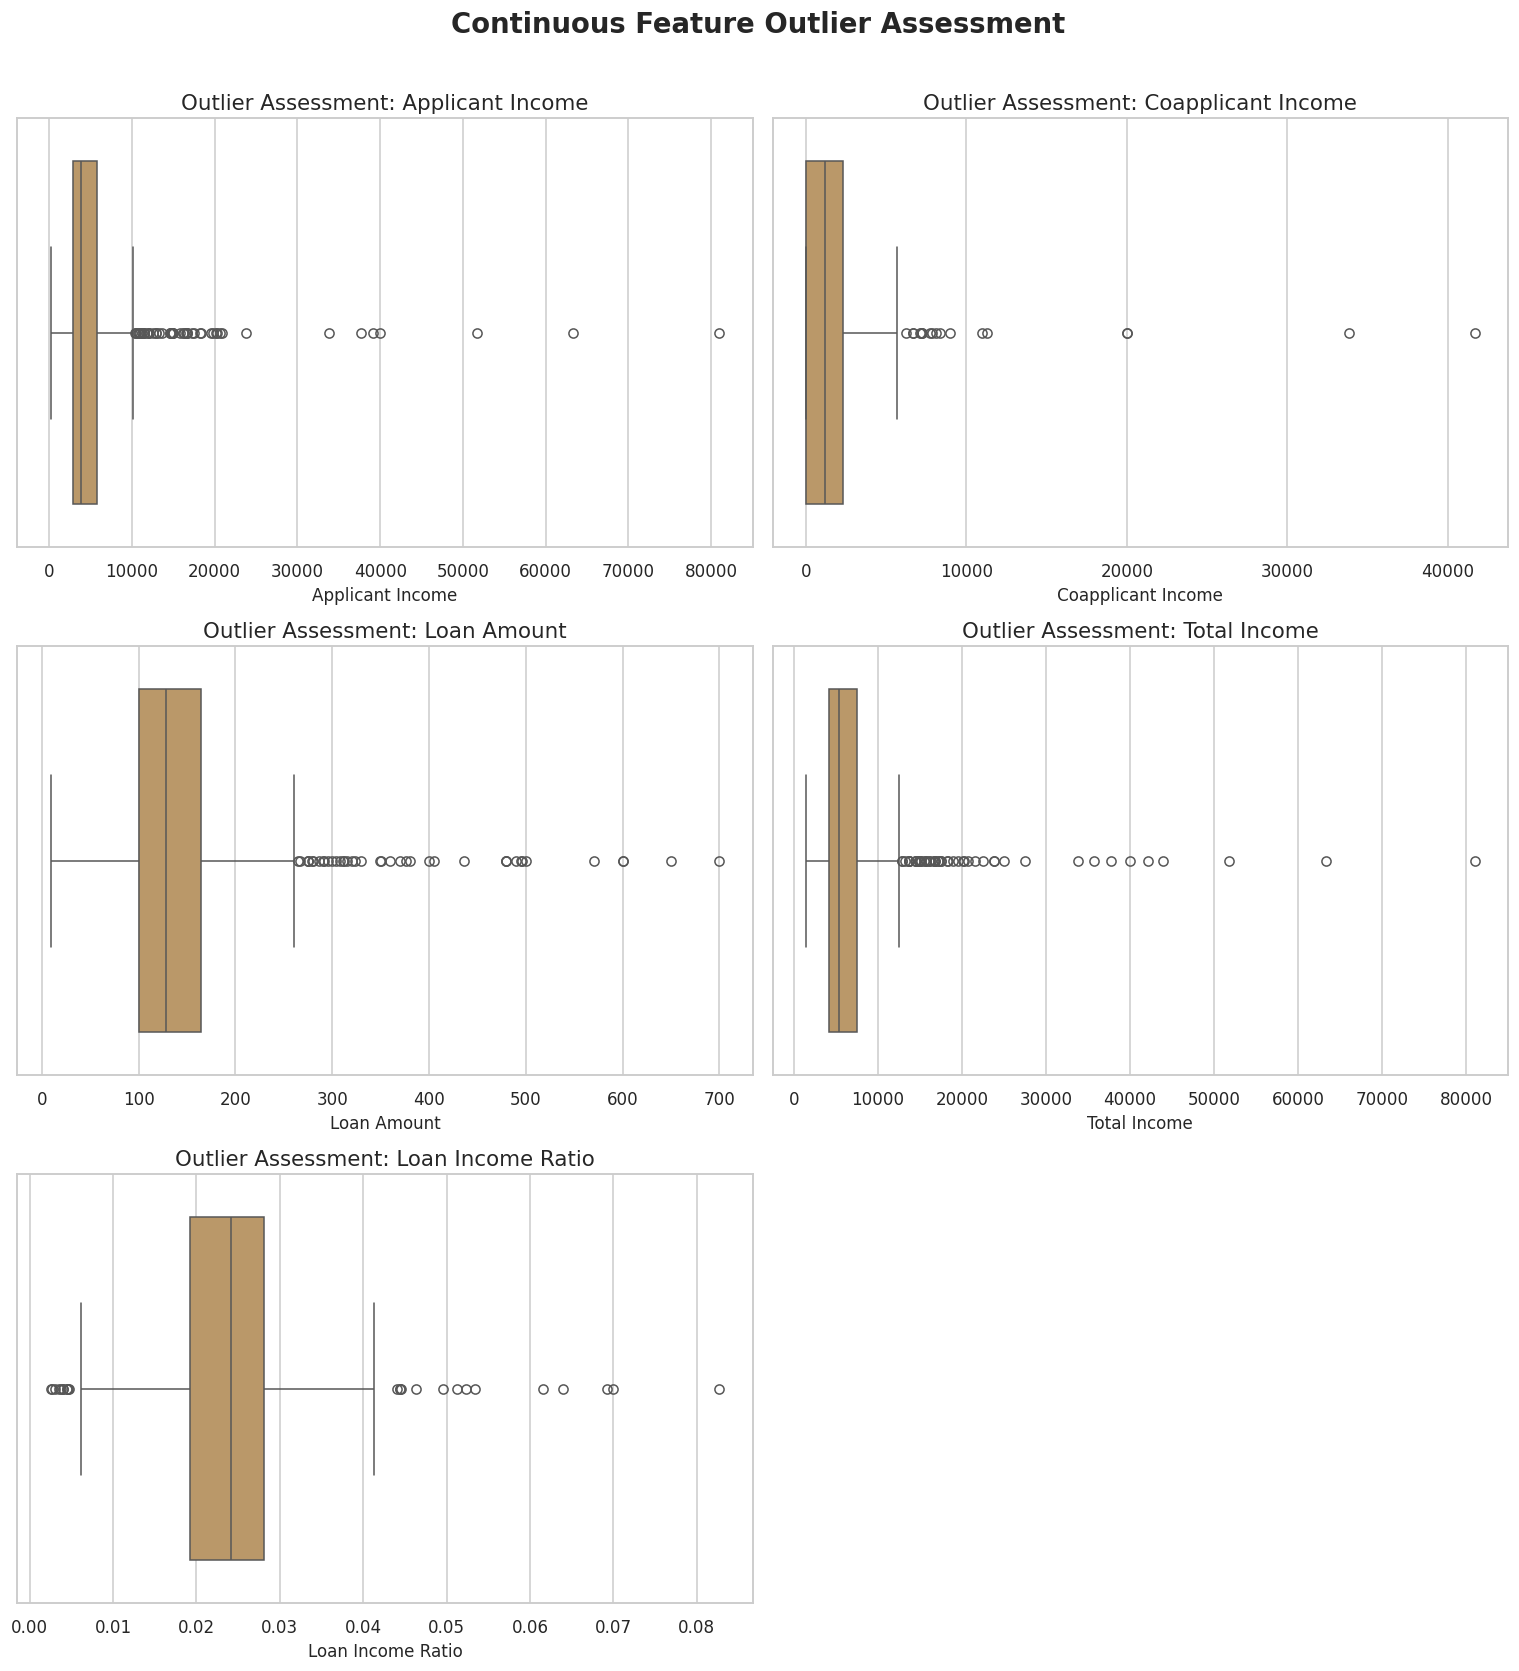

In [19]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 15)
)

axes = axes.flatten()

for index, column in enumerate(continuous_features):
    sns.boxplot(
        data=loan_df,
        x=column,
        ax=axes[index],
        color="#C79A5B"
    )

    axes[index].set_title(
        f"Outlier Assessment: {column.replace('_', ' ').title()}"
    )

    axes[index].set_xlabel(
        column.replace("_", " ").title()
    )

# Remove unused subplot
fig.delaxes(axes[-1])

plt.suptitle(
    "Continuous Feature Outlier Assessment",
    fontsize=18,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

### Interpretation

The boxplots will show several extreme observations, especially in income-related variables. However, the dataset provides no evidence that high incomes or large loans are data-entry errors.

### Assess target-class imbalance

In [20]:
class_summary = loan_df["loan_status"].value_counts().to_frame(
    name="count"
)

class_summary["percentage"] = (
    class_summary["count"] / len(loan_df) * 100
)

display(class_summary)

             count  percentage
loan_status                   
Y              422      68.730
N              192      31.270


### Imbalance ratio

In [21]:
majority_count = class_summary["count"].max()
minority_count = class_summary["count"].min()

imbalance_ratio = majority_count / minority_count

print(f"Class imbalance ratio: {imbalance_ratio:.2f}:1")

Class imbalance ratio: 2.20:1


### Class distribution chart

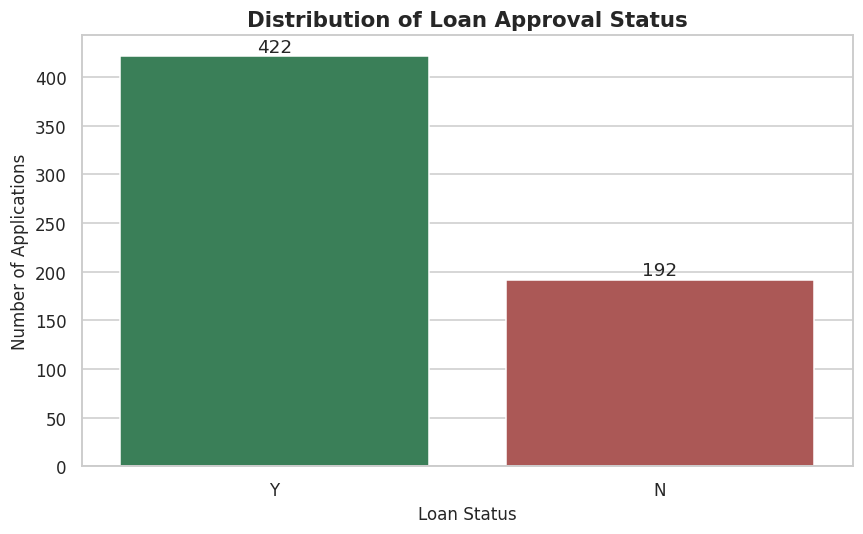

In [22]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=loan_df,
    x="loan_status",
    hue="loan_status",
    palette={"Y": "#2E8B57", "N": "#B94A48"},
    legend=False
)

plt.title(
    "Distribution of Loan Approval Status",
    fontweight="bold"
)

plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Class-Imbalance Findings

Approved applications account for 68.73% of the dataset, while rejected
applications account for 31.27%. The majority-to-minority ratio is
approximately 2.20:1.

The dataset therefore exhibits moderate class imbalance. Although both
classes contain enough observations for analysis, accuracy alone may provide
a misleading evaluation of future classification models.

Week 4 model evaluation should also consider precision, recall, F1-score,
ROC-AUC and the confusion matrix. Any resampling technique must be applied
only to the training data to prevent data leakage.

## Advanced Data Quality Assessment — Conclusion

The cleaned loan prediction dataset contains 614 observations and 14
variables. No missing values, exact duplicate records, negative financial
values or invalid categorical labels were detected.

The engineered `total_income` feature was verified and matched the sum of
applicant and coapplicant income for every record. The existing
`loan_income_ratio` was also mathematically consistent with its original
formula, although its unit interpretation requires revision during feature
engineering.

Income-related variables and loan amount were strongly right-skewed and
contained several IQR-identified extreme observations. These records were
retained because they remain financially possible and cannot be classified
as errors without additional domain evidence.

The loan target showed moderate class imbalance, with 68.73% approved and
31.27% rejected applications. Future models should therefore be evaluated
using metrics beyond accuracy.

Overall, the dataset is suitable for advanced exploratory and statistical
analysis, subject to careful treatment of skewness, feature redundancy,
class imbalance and the interpretation of engineered financial ratios.

# Part 2 — Advanced Exploratory Data Analysis

Exploratory data analysis identifies visible patterns, differences and relationships before formal statistical testing. The analysis moves from univariate distributions to bivariate comparisons and multivariate interactions. Exploratory findings are treated as hypotheses rather than proof of causation.


## 2.1 Define the analysis variables


In [23]:
continuous_features = [
    "applicant_income",
    "coapplicant_income",
    "loan_amount",
    "total_income",
    "loan_income_ratio",
]

categorical_features = [
    "gender",
    "married",
    "dependents",
    "education",
    "self_employed",
    "credit_history",
    "property_area",
    "loan_status",
]

# A numerical target supports rate and correlation calculations.
loan_df["approved"] = (
    loan_df["loan_status"]
    .astype(str)
    .str.strip()
    .eq("Y")
    .astype(int)
)

display(loan_df[["loan_status", "approved"]].head())


  loan_status  approved
0           Y         1
1           N         0
2           Y         1
3           Y         1
4           Y         1


## 2.2 Numerical distributions


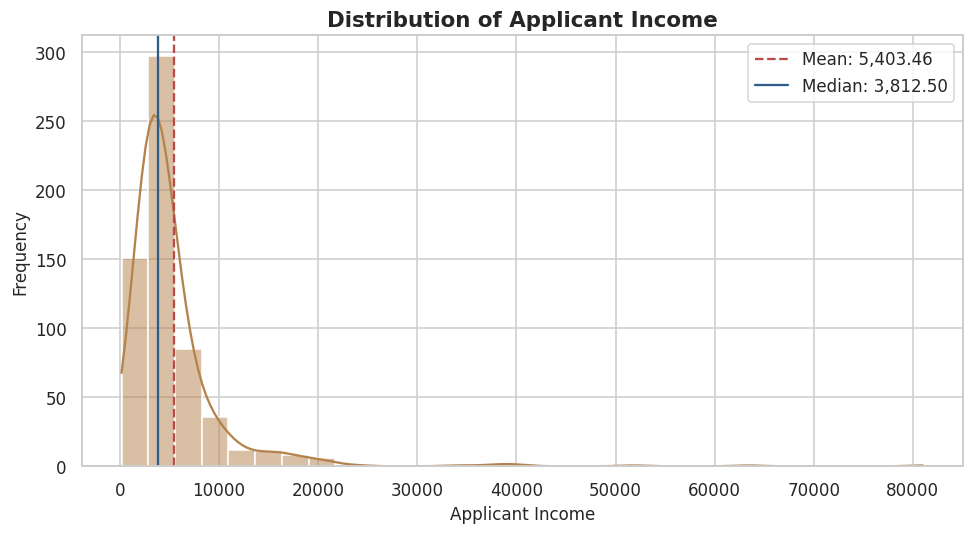

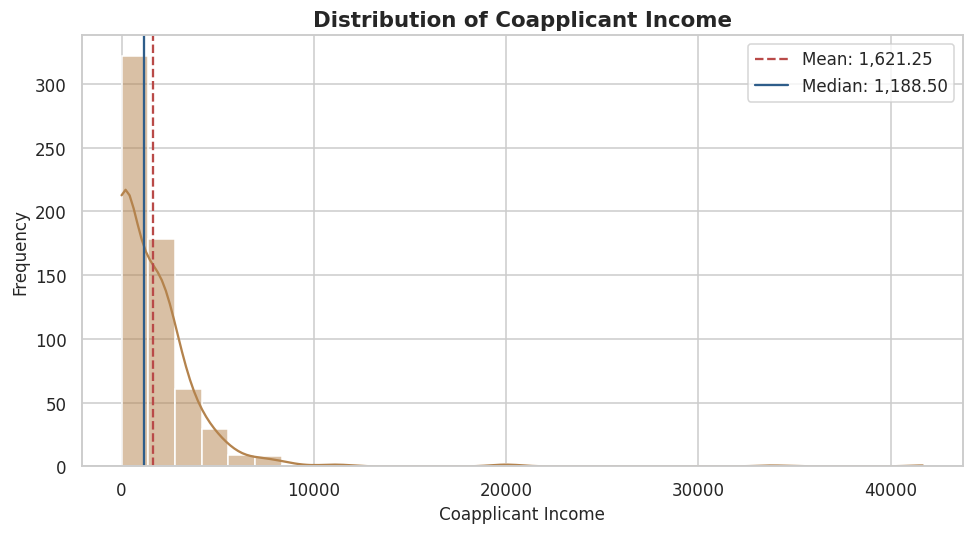

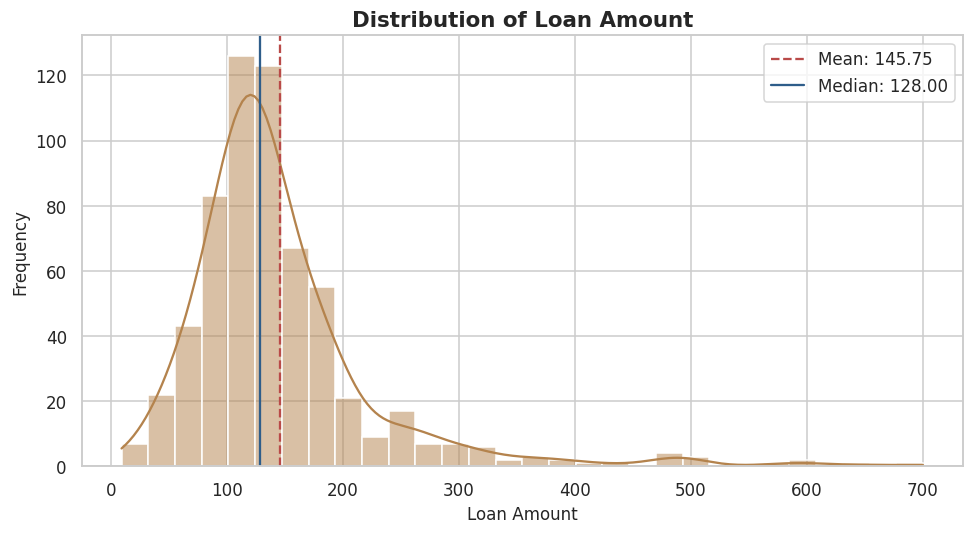

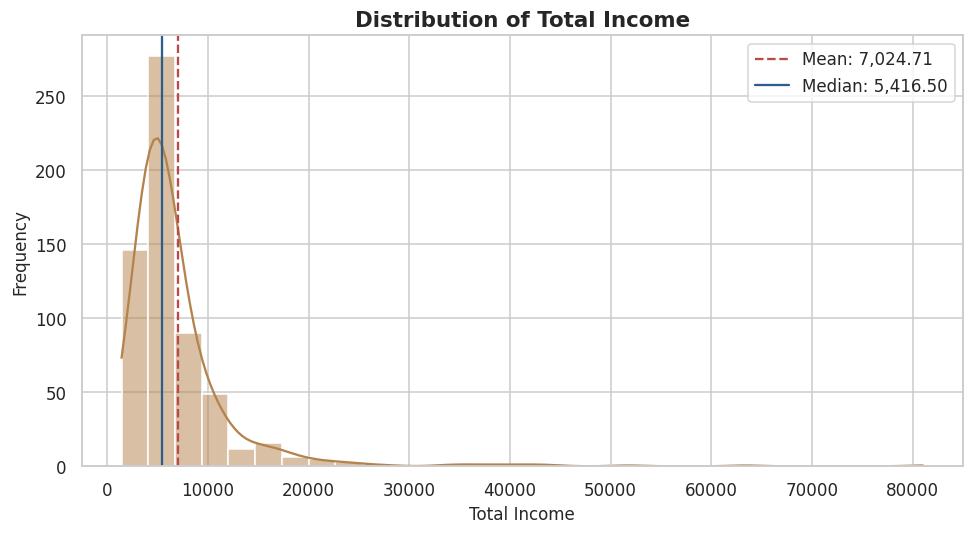

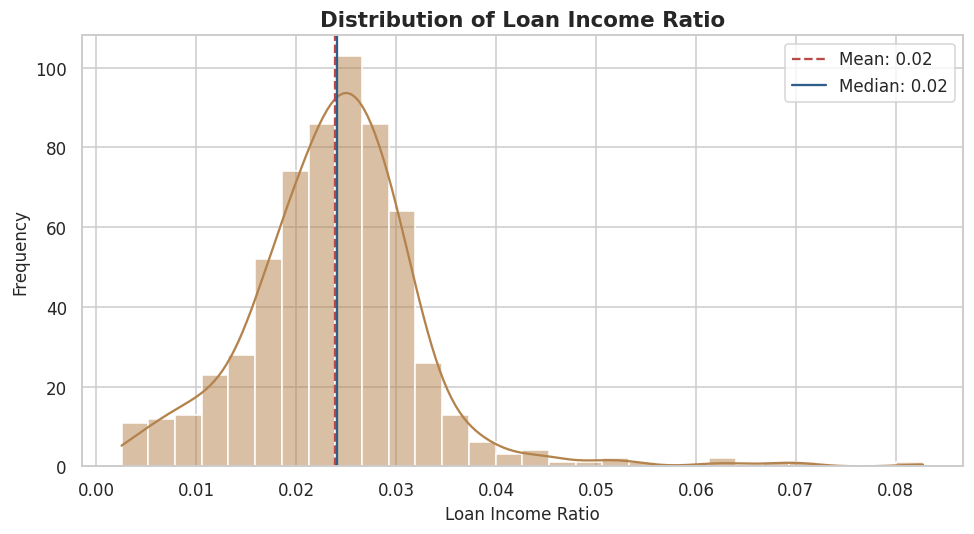

In [24]:
for column in continuous_features:
    plt.figure(figsize=(9, 5))
    sns.histplot(
        data=loan_df,
        x=column,
        bins=30,
        kde=True,
        color="#B4834D",
        edgecolor="white",
    )
    plt.axvline(
        loan_df[column].mean(),
        color="#B94A48",
        linestyle="--",
        label=f"Mean: {loan_df[column].mean():,.2f}",
    )
    plt.axvline(
        loan_df[column].median(),
        color="#2E5D8A",
        label=f"Median: {loan_df[column].median():,.2f}",
    )
    plt.title(f"Distribution of {column.replace('_', ' ').title()}", fontweight="bold")
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()


### Distribution interpretation

Applicant income, coapplicant income and total income are extremely right-skewed. Loan amount is also strongly right-skewed. The large differences between means and medians indicate that a small number of high-value observations influence the averages. Medians, rank-based tests and logarithmic transformations are therefore considered in later sections.


## 2.3 Separate density plots


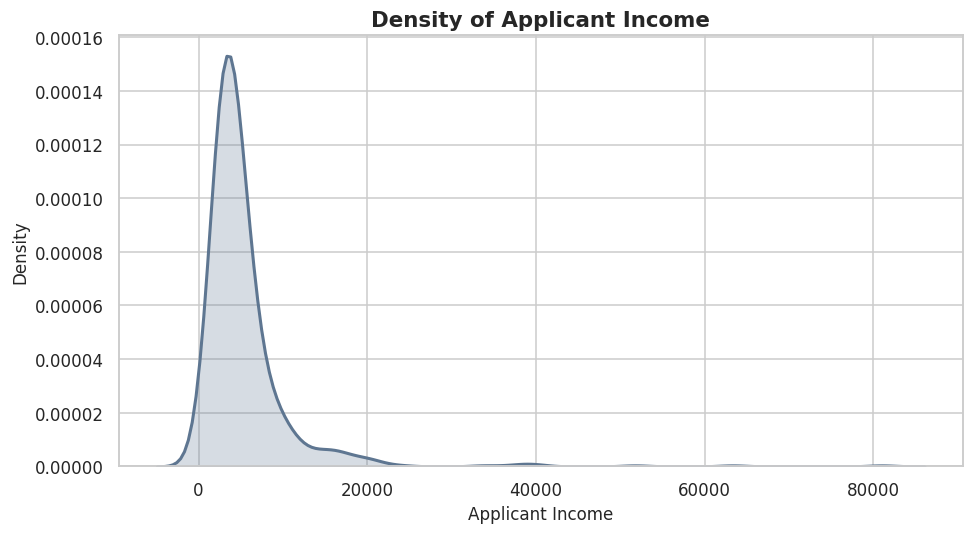

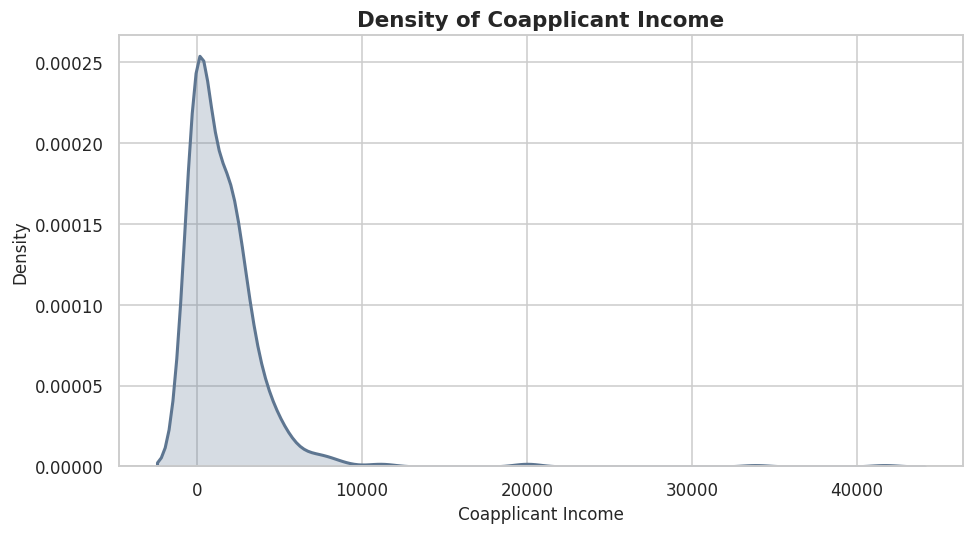

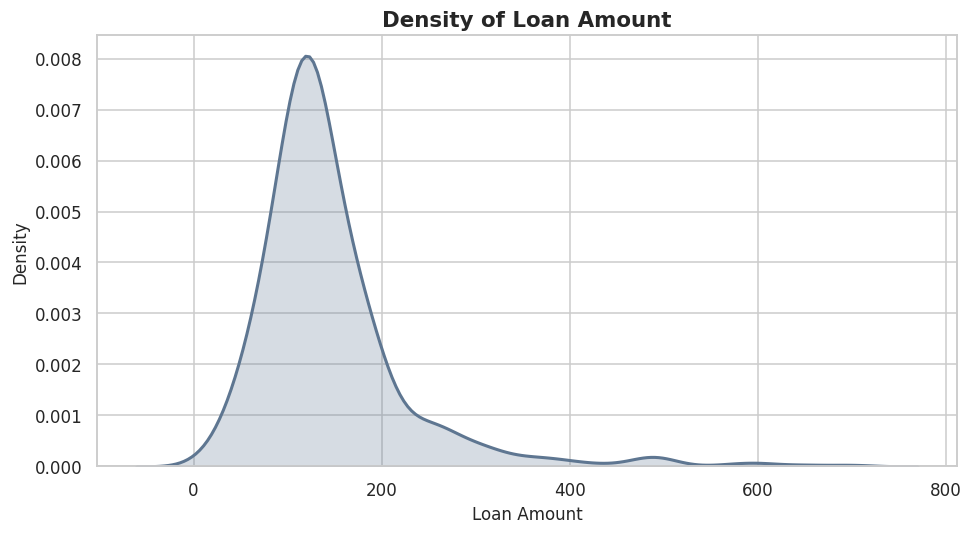

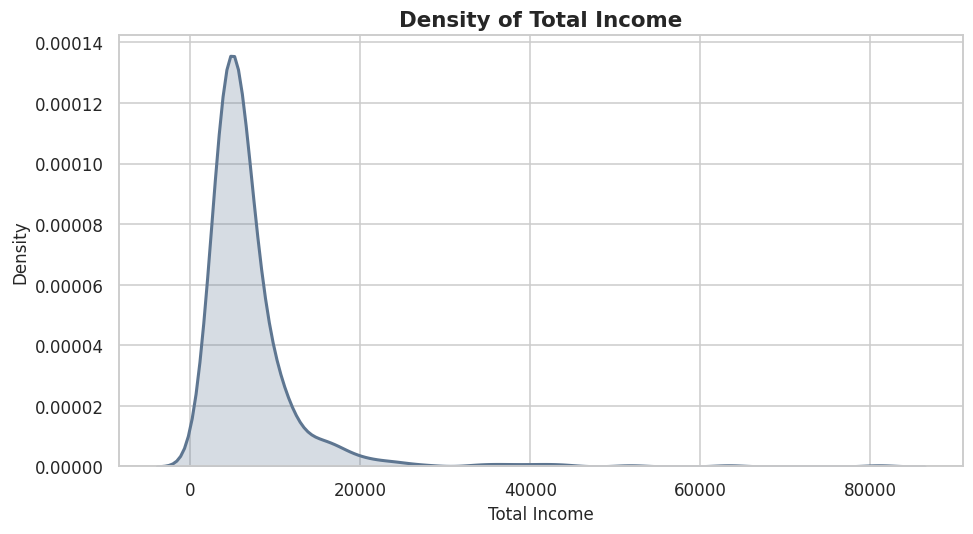

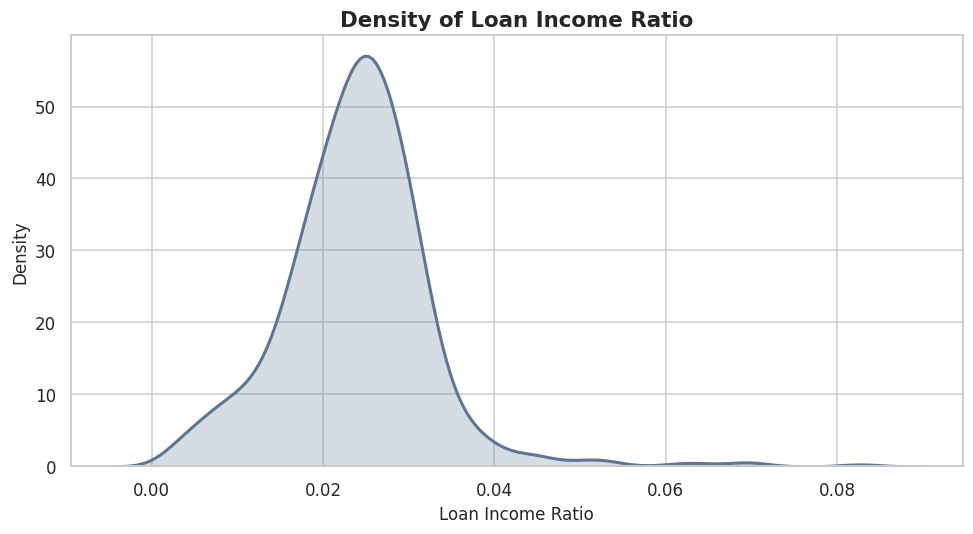

In [25]:
for column in continuous_features:
    plt.figure(figsize=(9, 5))
    sns.kdeplot(data=loan_df, x=column, fill=True, color="#5E7691", linewidth=2)
    plt.title(f"Density of {column.replace('_', ' ').title()}", fontweight="bold")
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()


## 2.4 Log-transformed financial distributions


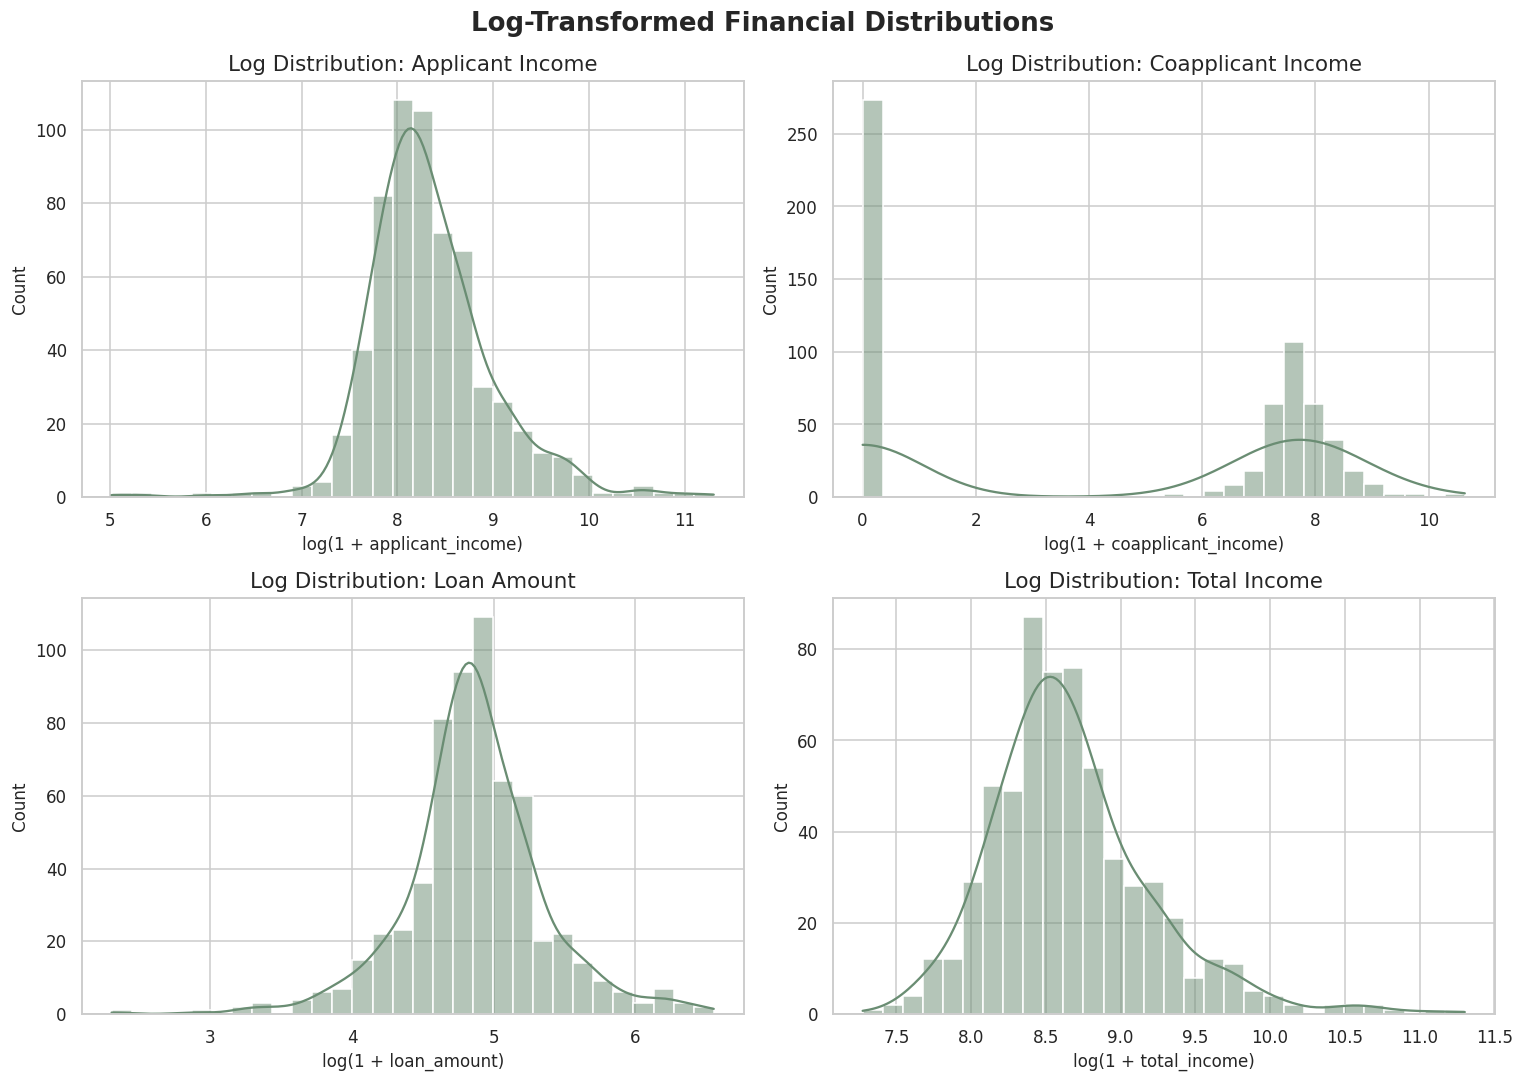

In [26]:
log_features = [
    "applicant_income",
    "coapplicant_income",
    "loan_amount",
    "total_income",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for index, column in enumerate(log_features):
    sns.histplot(np.log1p(loan_df[column]), bins=30, kde=True, ax=axes[index], color="#6A8D73")
    axes[index].set_title(f"Log Distribution: {column.replace('_', ' ').title()}")
    axes[index].set_xlabel(f"log(1 + {column})")

plt.suptitle("Log-Transformed Financial Distributions", fontsize=17, fontweight="bold")
plt.tight_layout()
plt.show()


The `log1p` transformation compresses extreme positive values while retaining every observation. Adding one makes the transformation safe for zero coapplicant-income values. The original features are retained until feature selection.


## 2.5 Loan-term distribution


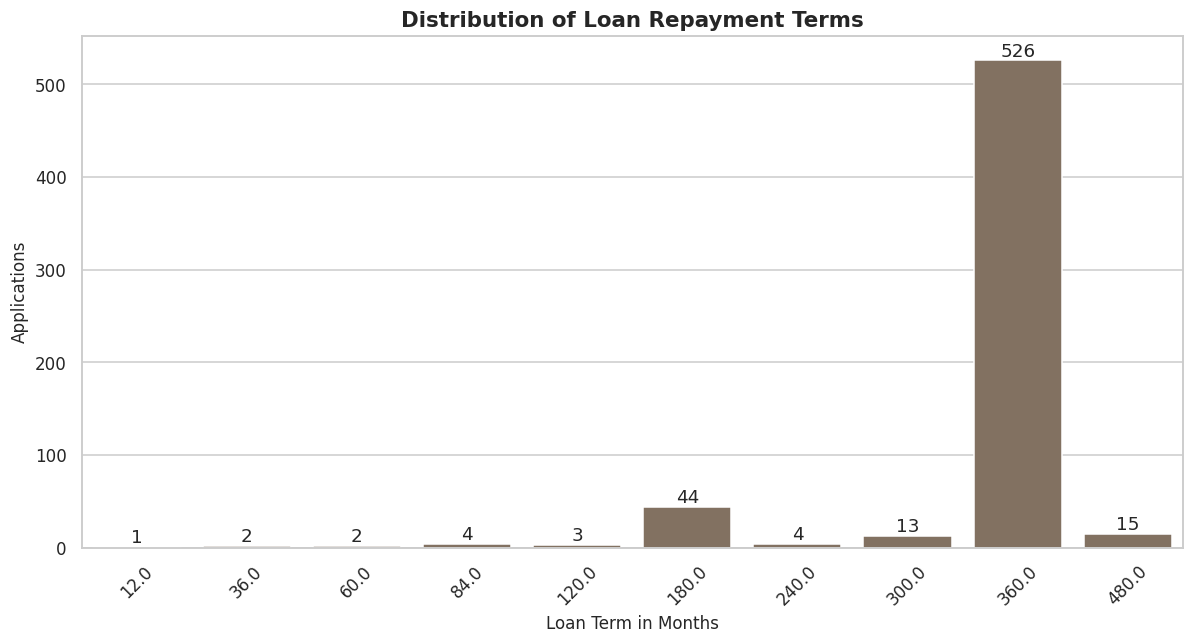

In [27]:
term_order = sorted(loan_df["loan_amount_term"].unique())

plt.figure(figsize=(11, 6))
ax = sns.countplot(data=loan_df, x="loan_amount_term", order=term_order, color="#87715B")
plt.title("Distribution of Loan Repayment Terms", fontweight="bold")
plt.xlabel("Loan Term in Months")
plt.ylabel("Applications")
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()


The repayment term is concentrated at 360 months, or 30 years. Because it is a discrete contractual variable, less-common terms should not be deleted merely because an IQR rule labels them unusual.


## 2.6 Categorical frequency and percentage analysis


In [28]:
predictor_categories = [
    "gender",
    "married",
    "dependents",
    "education",
    "self_employed",
    "credit_history",
    "property_area",
]

categorical_summary_tables = {}
for column in predictor_categories:
    table = loan_df[column].value_counts(dropna=False).to_frame(name="frequency")
    table["percentage"] = table["frequency"] / len(loan_df) * 100
    categorical_summary_tables[column] = table
    print()
    print(column.upper())
    display(table.round(2))



GENDER
        frequency  percentage
gender                       
Male          502      81.760
Female        112      18.240

MARRIED
         frequency  percentage
married                       
Yes            401      65.310
No             213      34.690

DEPENDENTS
            frequency  percentage
dependents                       
0                 360      58.630
1                 102      16.610
2                 101      16.450
3+                 51       8.310

EDUCATION
              frequency  percentage
education                          
Graduate            480      78.180
Not Graduate        134      21.820

SELF_EMPLOYED
               frequency  percentage
self_employed                       
No                   532      86.640
Yes                   82      13.360

CREDIT_HISTORY
                frequency  percentage
credit_history                       
1.000                 525      85.500
0.000                  89      14.500

PROPERTY_AREA
               frequen

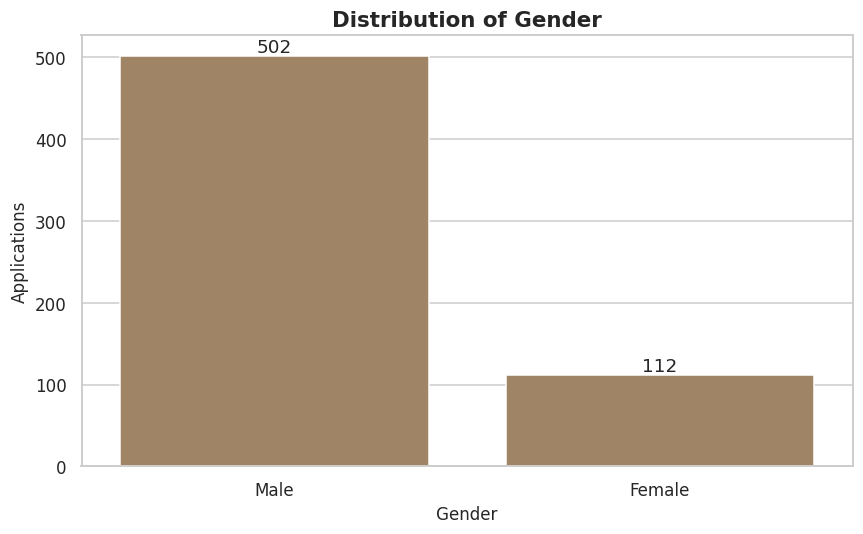

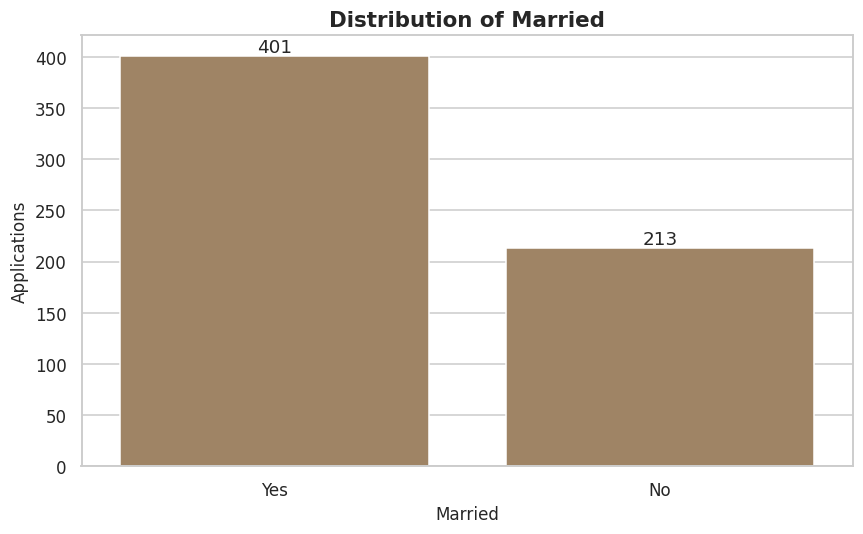

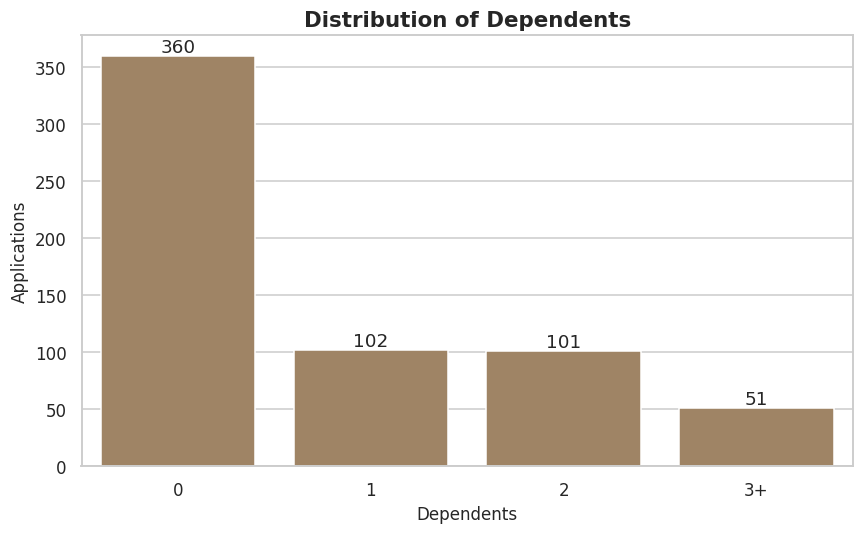

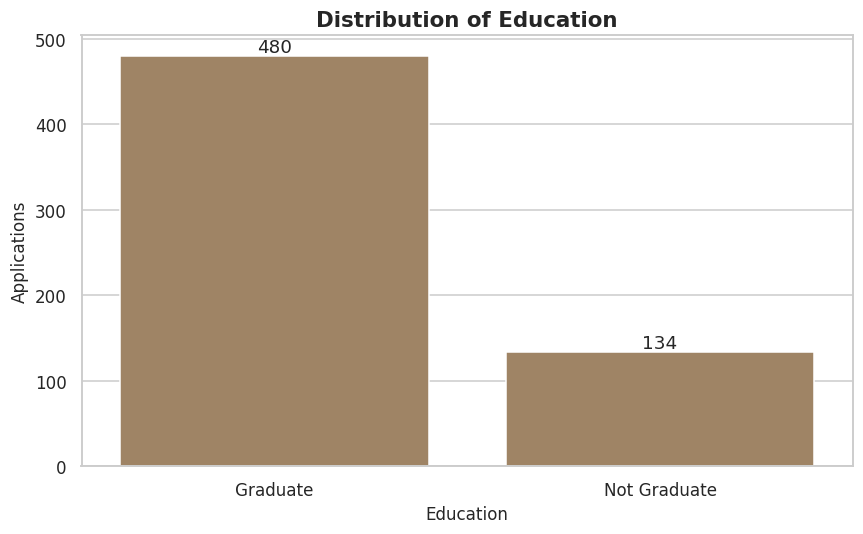

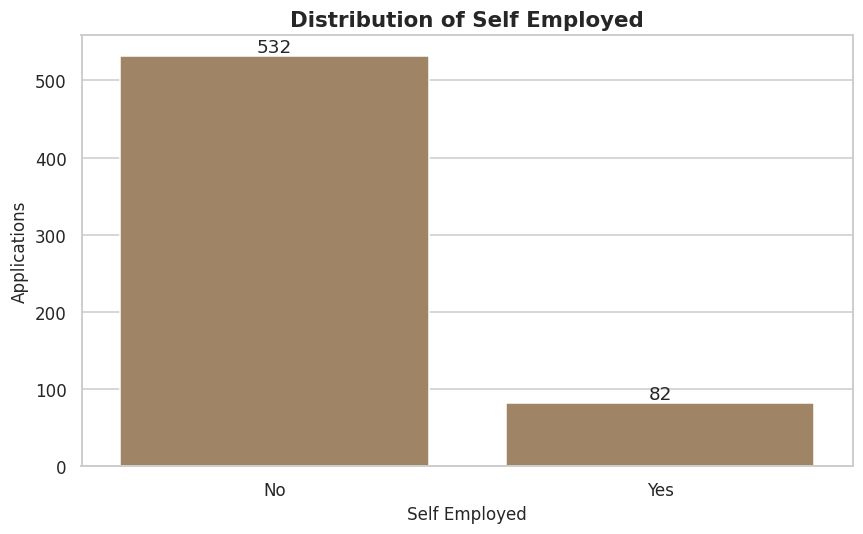

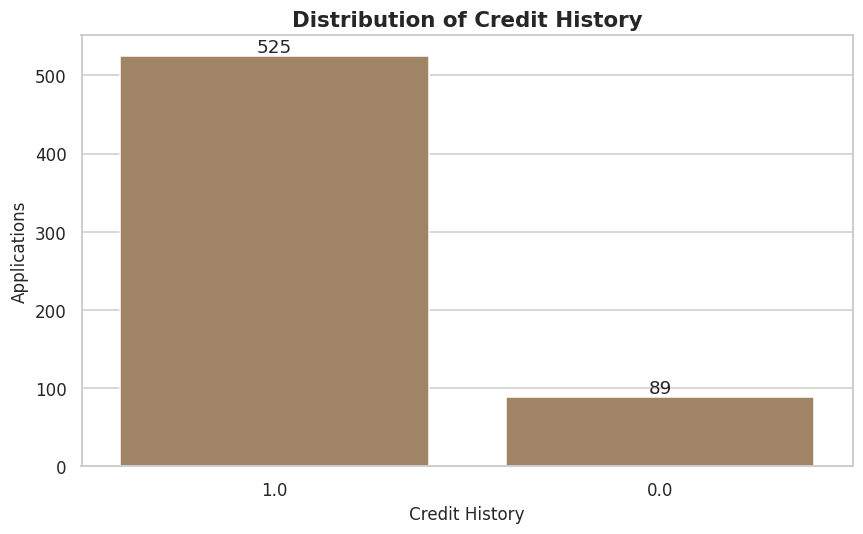

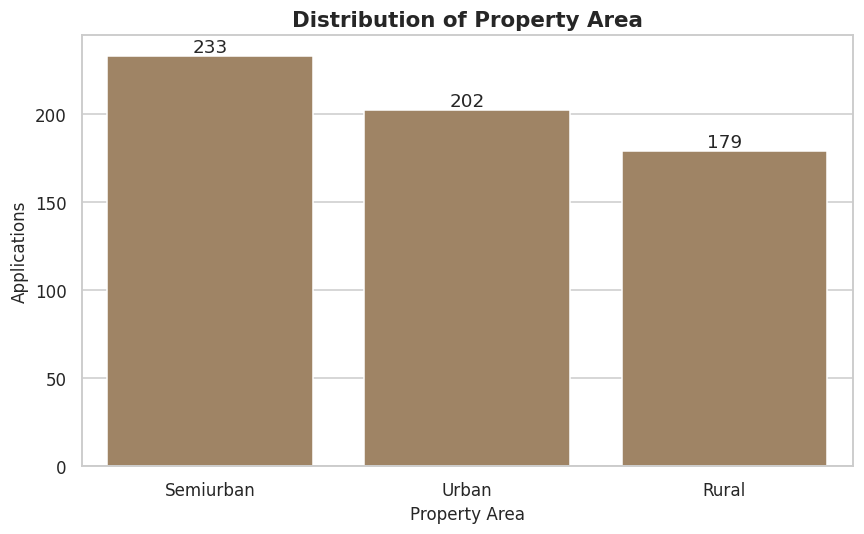

In [29]:
for column in predictor_categories:
    plt.figure(figsize=(8, 5))
    order = loan_df[column].value_counts().index
    ax = sns.countplot(data=loan_df, x=column, order=order, color="#A9855B")
    plt.title(f"Distribution of {column.replace('_', ' ').title()}", fontweight="bold")
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel("Applications")
    for container in ax.containers:
        ax.bar_label(container)
    plt.tight_layout()
    plt.show()


## 2.7 Categorical variables versus loan approval



Approval summary: credit_history
   credit_history  applications  approved_applications  approval_rate  \
1           1.000           525                    415          0.790   
0           0.000            89                      7          0.080   

   approval_rate_percentage  
1                    79.050  
0                     7.870  

Approval summary: property_area
  property_area  applications  approved_applications  approval_rate  \
1     Semiurban           233                    179          0.770   
2         Urban           202                    133          0.660   
0         Rural           179                    110          0.610   

   approval_rate_percentage  
1                    76.820  
2                    65.840  
0                    61.450  

Approval summary: education
      education  applications  approved_applications  approval_rate  \
0      Graduate           480                    340          0.710   
1  Not Graduate           134                  

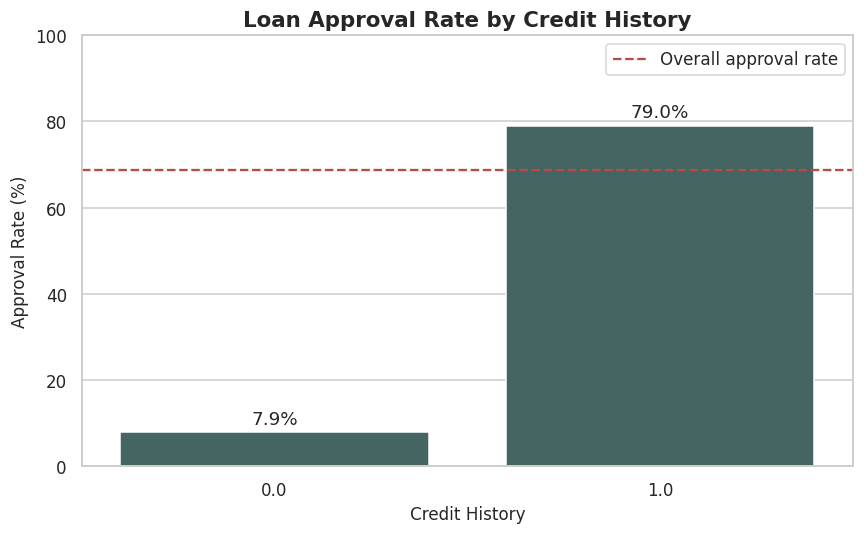

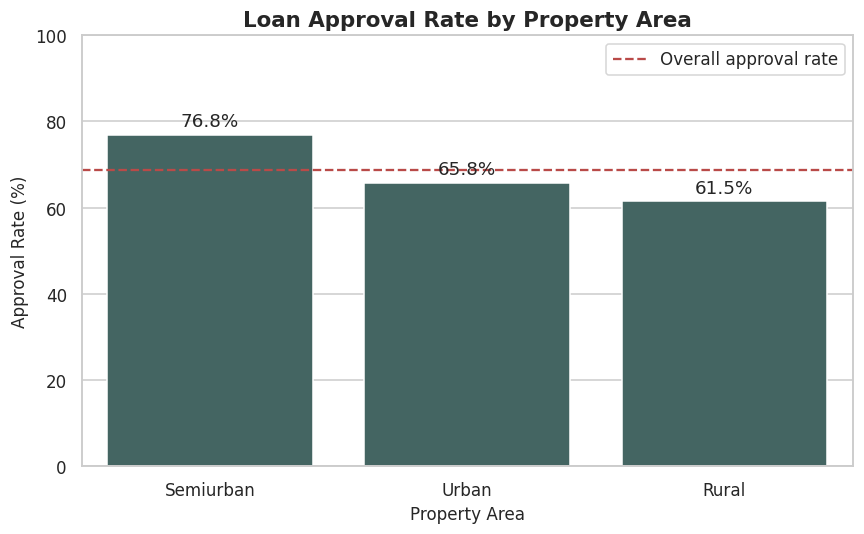

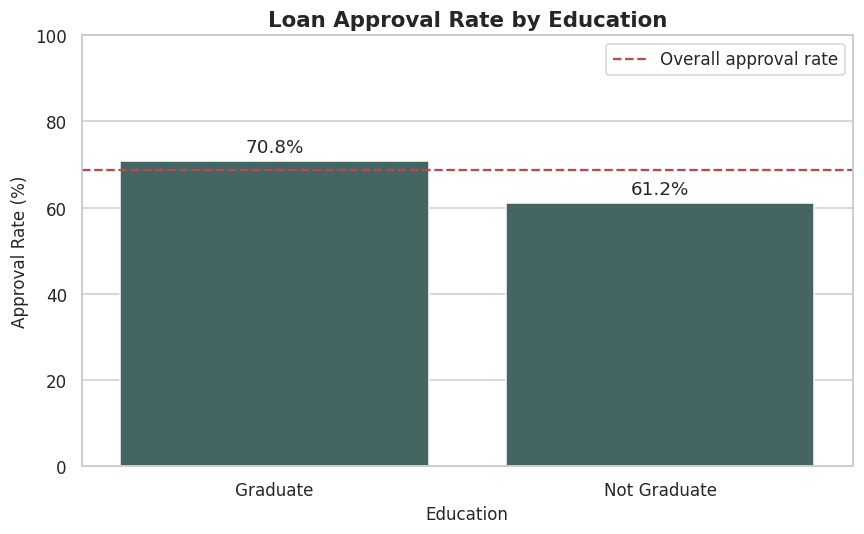

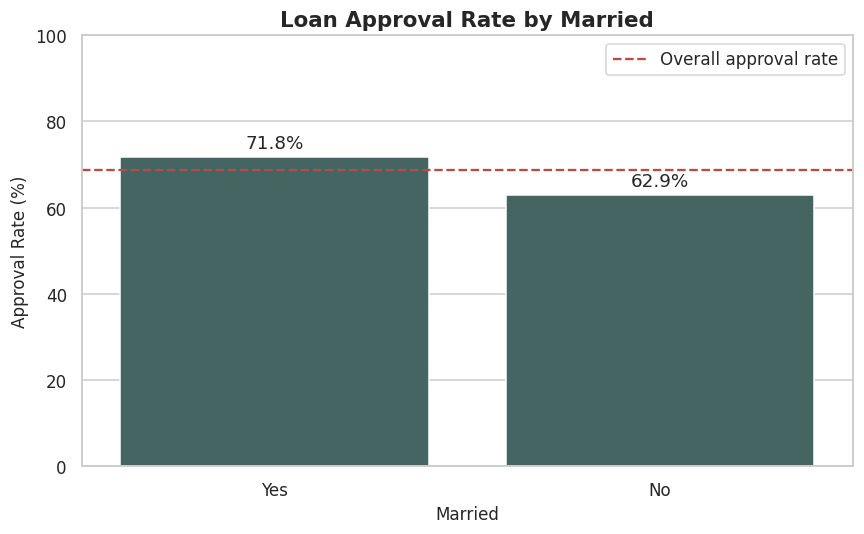

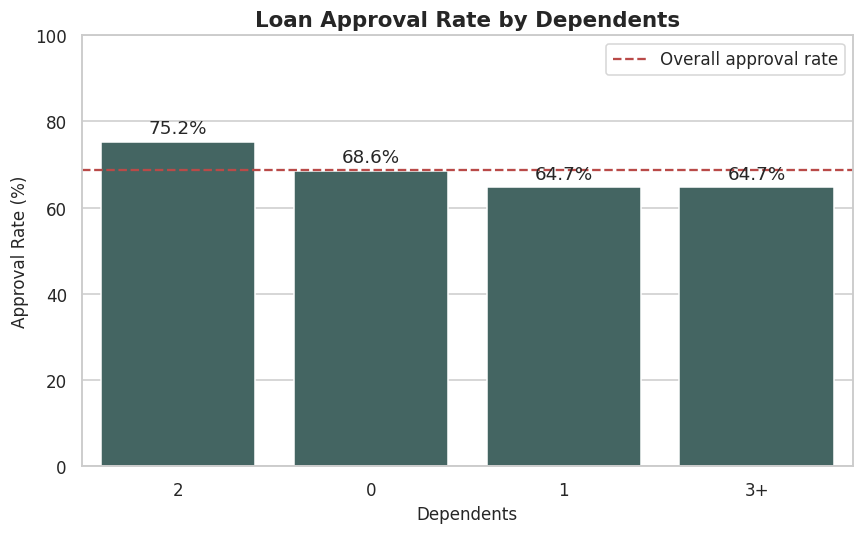

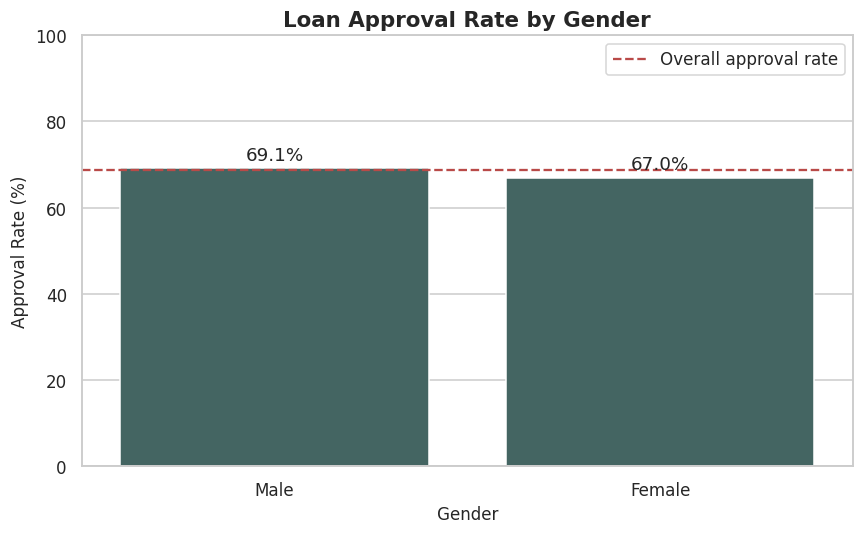

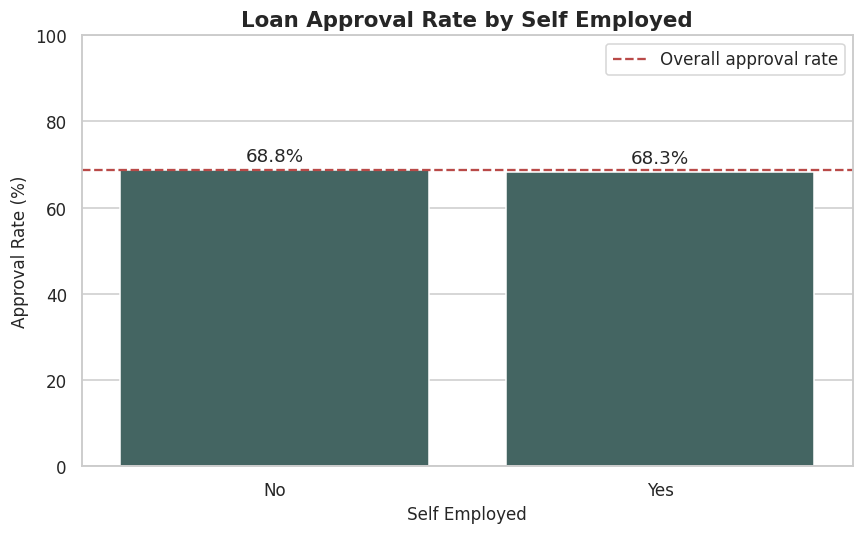

In [30]:
def approval_rate_table(data, feature):
    required = {feature, "approved"}
    missing = required.difference(data.columns)
    if missing:
        raise KeyError(f"Missing required columns: {sorted(missing)}")

    table = (
        data.groupby(feature, dropna=False)
        .agg(
            applications=("approved", "size"),
            approved_applications=("approved", "sum"),
            approval_rate=("approved", "mean"),
        )
        .reset_index()
    )
    table["approval_rate_percentage"] = table["approval_rate"] * 100
    return table.sort_values("approval_rate_percentage", ascending=False)


approval_features = [
    "credit_history",
    "property_area",
    "education",
    "married",
    "dependents",
    "gender",
    "self_employed",
]

for column in approval_features:
    plot_data = approval_rate_table(loan_df, column)
    print()
    print(f"Approval summary: {column}")
    display(plot_data.round(2))

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(data=plot_data, x=column, y="approval_rate_percentage", color="#3E6B67")
    plt.axhline(
        loan_df["approved"].mean() * 100,
        color="#B94A48",
        linestyle="--",
        label="Overall approval rate",
    )
    plt.title(f"Loan Approval Rate by {column.replace('_', ' ').title()}", fontweight="bold")
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel("Approval Rate (%)")
    plt.ylim(0, 100)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3)
    plt.legend()
    plt.tight_layout()
    plt.show()


### Approval-rate findings

- Positive credit history has the largest visible difference: 79.05% approval compared with 7.87% for applicants without positive credit history.
- Semiurban applicants have the highest property-area approval rate at 76.82%, followed by urban applicants at 65.84% and rural applicants at 61.45%.
- Graduates have a 70.83% approval rate compared with 61.19% for non-graduates.
- Married applicants have a 71.82% approval rate compared with 62.91% for unmarried applicants.
- Gender and self-employment show comparatively small approval-rate differences.

These are descriptive relationships. Statistical significance and effect size are evaluated in Part 3.


## 2.8 Cross-tabulations and row percentages


In [31]:
for column in approval_features:
    count_table = pd.crosstab(loan_df[column], loan_df["loan_status"])
    percentage_table = pd.crosstab(
        loan_df[column],
        loan_df["loan_status"],
        normalize="index",
    ) * 100
    print()
    print(f"{column.upper()} — COUNTS")
    display(count_table)
    print(f"{column.upper()} — ROW PERCENTAGES")
    display(percentage_table.round(2))



CREDIT_HISTORY — COUNTS
loan_status       N    Y
credit_history          
0.000            82    7
1.000           110  415
CREDIT_HISTORY — ROW PERCENTAGES
loan_status         N      Y
credit_history              
0.000          92.130  7.870
1.000          20.950 79.050

PROPERTY_AREA — COUNTS
loan_status     N    Y
property_area         
Rural          69  110
Semiurban      54  179
Urban          69  133
PROPERTY_AREA — ROW PERCENTAGES
loan_status        N      Y
property_area              
Rural         38.550 61.450
Semiurban     23.180 76.820
Urban         34.160 65.840

EDUCATION — COUNTS
loan_status     N    Y
education             
Graduate      140  340
Not Graduate   52   82
EDUCATION — ROW PERCENTAGES
loan_status       N      Y
education                 
Graduate     29.170 70.830
Not Graduate 38.810 61.190

MARRIED — COUNTS
loan_status    N    Y
married              
No            79  134
Yes          113  288
MARRIED — ROW PERCENTAGES
loan_status      N      Y
married  

## 2.9 Numerical variables versus loan status


In [32]:
numerical_by_status = (
    loan_df.groupby("loan_status")[continuous_features + ["loan_amount_term"]]
    .agg(["count", "mean", "median", "std"])
    .T
)
display(numerical_by_status.round(3))


loan_status                       N         Y
applicant_income   count    192.000   422.000
                   mean   5,446.078 5,384.069
                   median 3,833.500 3,812.500
                   std    6,819.559 5,765.442
coapplicant_income count    192.000   422.000
                   mean   1,877.807 1,504.516
                   median   268.000 1,239.500
                   std    4,384.060 1,924.755
loan_amount        count    192.000   422.000
                   mean     149.891   143.870
                   median   128.000   128.000
                   std       83.529    84.400
total_income       count    192.000   422.000
                   mean   7,323.885 6,888.585
                   median 5,289.500 5,439.000
                   std    7,739.774 5,788.062
loan_income_ratio  count    192.000   422.000
                   mean       0.025     0.023
                   median     0.024     0.024
                   std        0.010     0.008
loan_amount_term   count    192.00

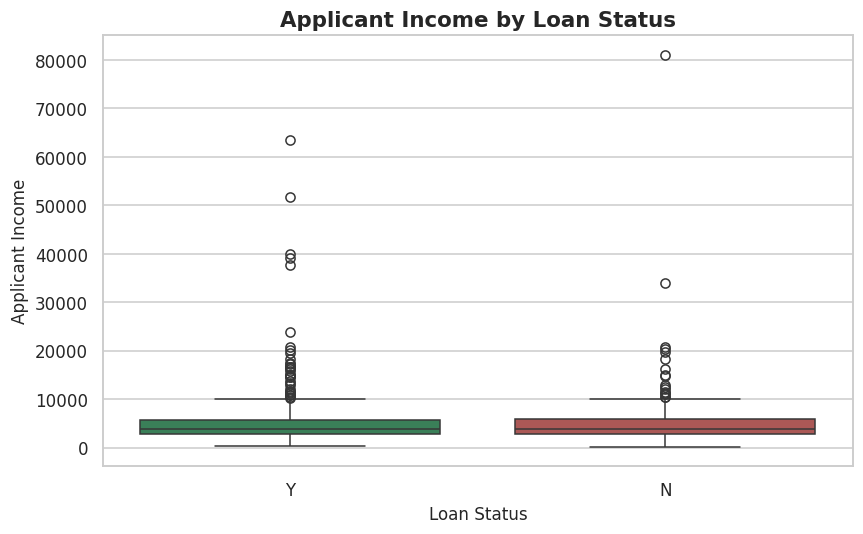

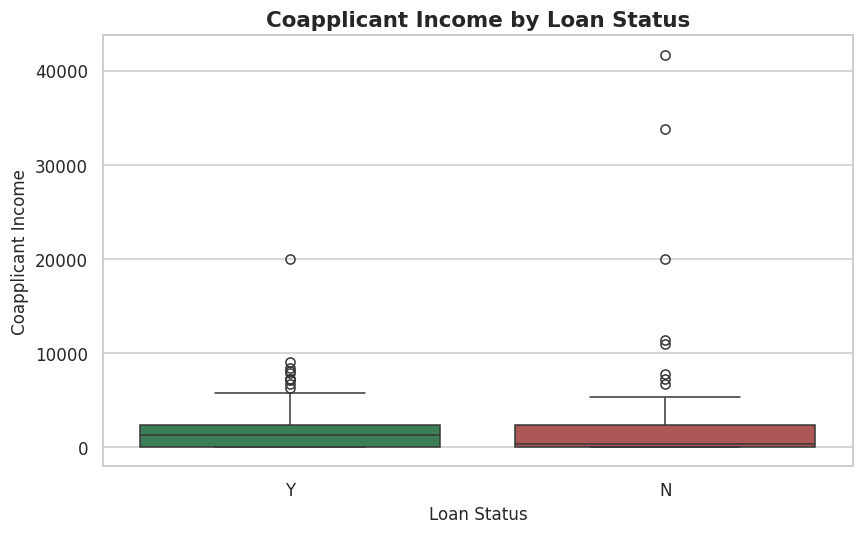

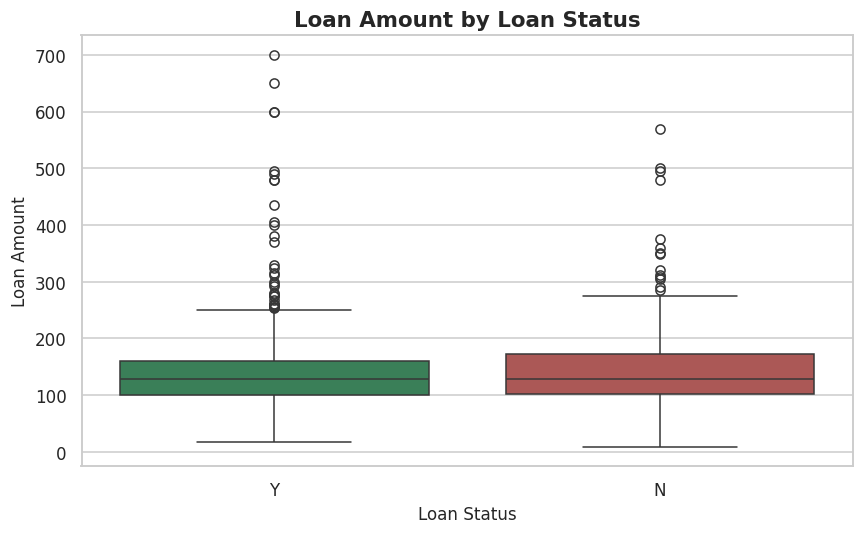

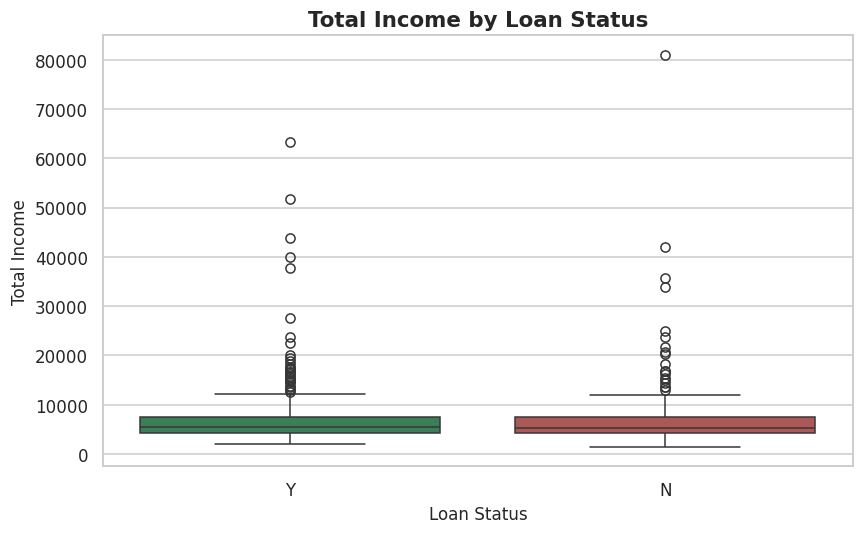

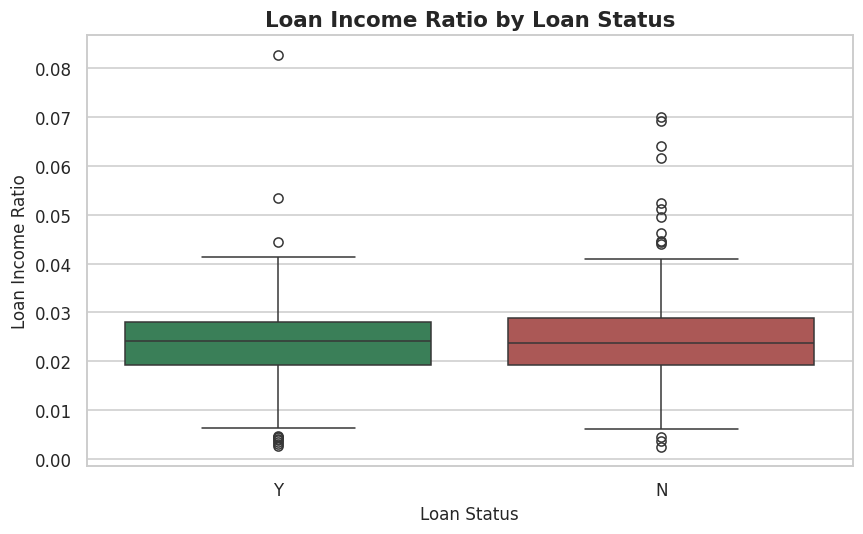

In [33]:
for column in continuous_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=loan_df,
        x="loan_status",
        y=column,
        hue="loan_status",
        palette={"Y": "#2E8B57", "N": "#B94A48"},
        legend=False,
    )
    plt.title(f"{column.replace('_', ' ').title()} by Loan Status", fontweight="bold")
    plt.xlabel("Loan Status")
    plt.ylabel(column.replace("_", " ").title())
    plt.tight_layout()
    plt.show()


The medians for applicant income, loan amount and loan term are almost identical across approval groups. Considerable distribution overlap suggests that financial size variables alone may not distinguish approval outcomes effectively.


## 2.10 Correlation analysis


In [34]:
correlation_features = [
    "applicant_income",
    "coapplicant_income",
    "loan_amount",
    "loan_amount_term",
    "credit_history",
    "total_income",
    "loan_income_ratio",
    "approved",
]

pearson_correlation = loan_df[correlation_features].corr(method="pearson")
spearman_correlation = loan_df[correlation_features].corr(method="spearman")

print("Pearson correlation")
display(pearson_correlation.round(3))
print("Spearman correlation")
display(spearman_correlation.round(3))


Pearson correlation
                    applicant_income  coapplicant_income  loan_amount  \
applicant_income               1.000              -0.117        0.565   
coapplicant_income            -0.117               1.000        0.189   
loan_amount                    0.565               0.189        1.000   
loan_amount_term              -0.047              -0.059        0.037   
credit_history                -0.019               0.011       -0.001   
total_income                   0.893               0.343        0.620   
loan_income_ratio             -0.317              -0.201        0.153   
approved                      -0.005              -0.059       -0.033   

                    loan_amount_term  credit_history  total_income  \
applicant_income              -0.047          -0.019         0.893   
coapplicant_income            -0.059           0.011         0.343   
loan_amount                    0.037          -0.001         0.620   
loan_amount_term               1.000      

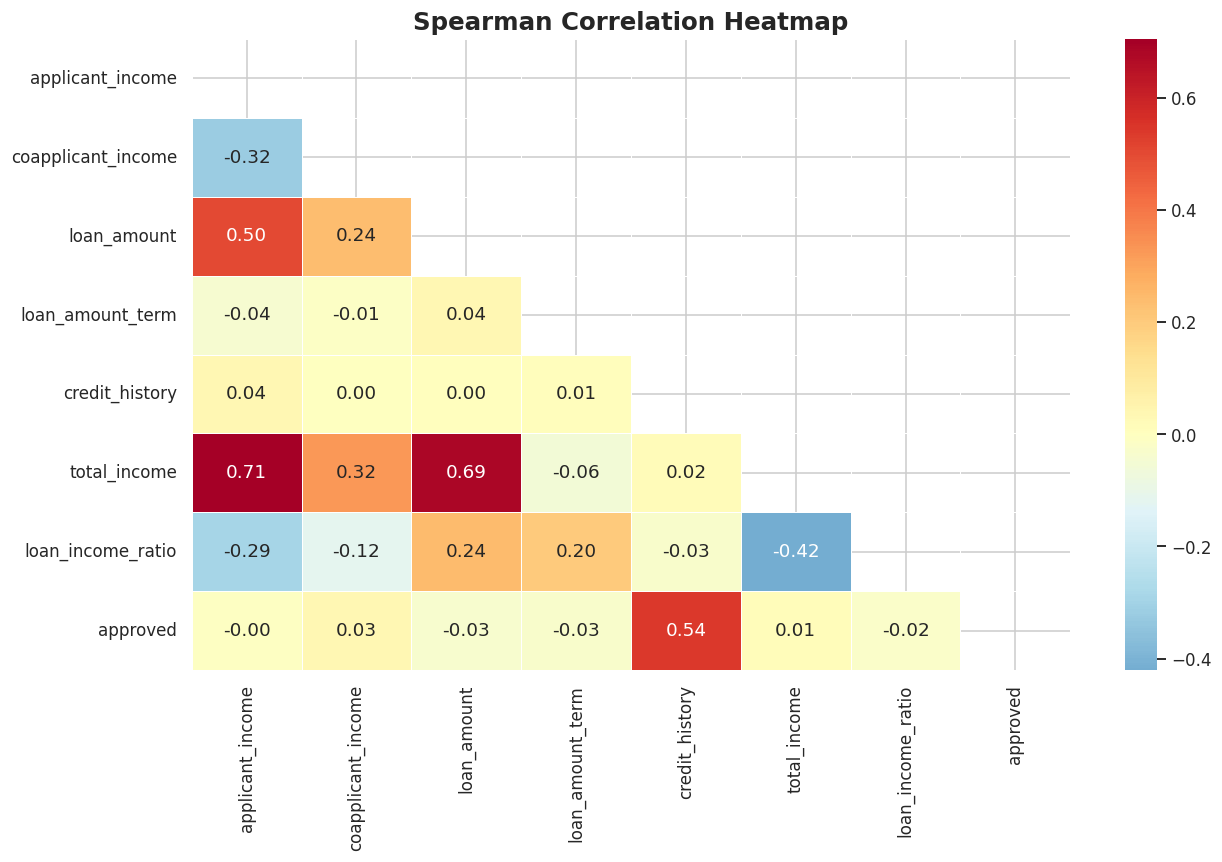

In [35]:
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(spearman_correlation, dtype=bool))
sns.heatmap(
    spearman_correlation,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    center=0,
    linewidths=0.5,
)
plt.title("Spearman Correlation Heatmap", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


Applicant income and total income have a Pearson correlation of approximately 0.893 because applicant income is part of the total-income formula. This is mathematical redundancy. Credit history has the strongest observed relationship with approval, while most standalone financial variables have weak direct relationships with the target.


## 2.11 Numerical and multivariate relationships


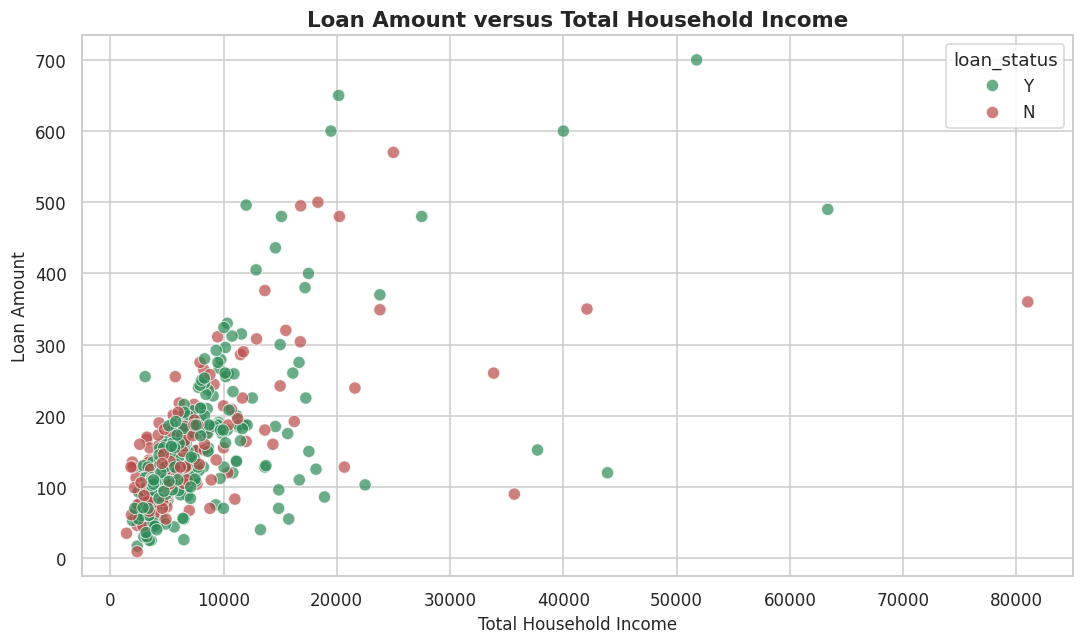

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=loan_df,
    x="total_income",
    y="loan_amount",
    hue="loan_status",
    palette={"Y": "#2E8B57", "N": "#B94A48"},
    alpha=0.7,
    s=65,
)
plt.title("Loan Amount versus Total Household Income", fontweight="bold")
plt.xlabel("Total Household Income")
plt.ylabel("Loan Amount")
plt.tight_layout()
plt.show()


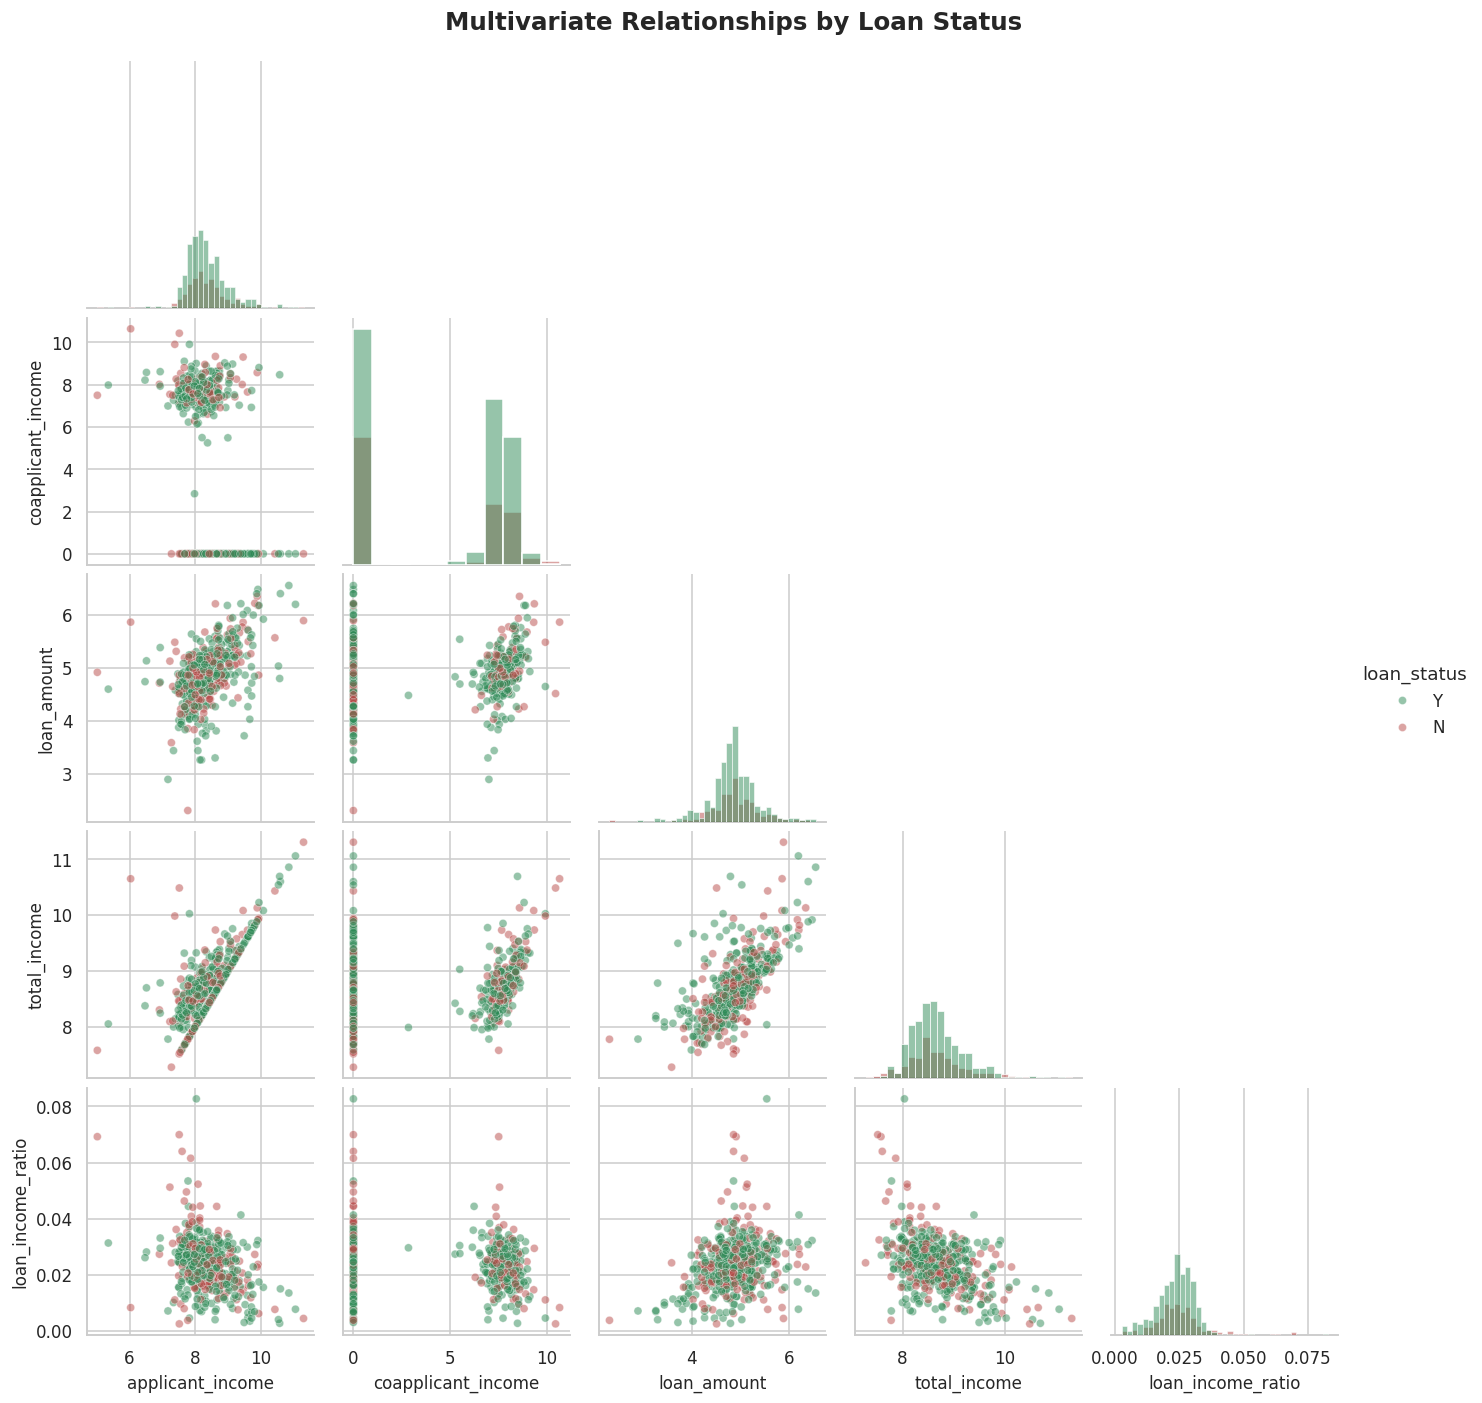

In [37]:
pairplot_data = loan_df[[
    "applicant_income",
    "coapplicant_income",
    "loan_amount",
    "total_income",
    "loan_income_ratio",
    "loan_status",
]].copy()

for column in ["applicant_income", "coapplicant_income", "loan_amount", "total_income"]:
    pairplot_data[column] = np.log1p(pairplot_data[column])

grid = sns.pairplot(
    pairplot_data,
    hue="loan_status",
    palette={"Y": "#2E8B57", "N": "#B94A48"},
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.50, "s": 28},
)
grid.fig.suptitle("Multivariate Relationships by Loan Status", y=1.02, fontsize=16, fontweight="bold")
plt.show()


   credit_history property_area  applications  approval_rate  \
0           0.000         Rural            28          0.070   
1           0.000     Semiurban            30          0.130   
2           0.000         Urban            31          0.030   
3           1.000         Rural           151          0.720   
4           1.000     Semiurban           203          0.860   
5           1.000         Urban           171          0.770   

   approval_rate_percentage  
0                     7.140  
1                    13.330  
2                     3.230  
3                    71.520  
4                    86.210  
5                    77.190  


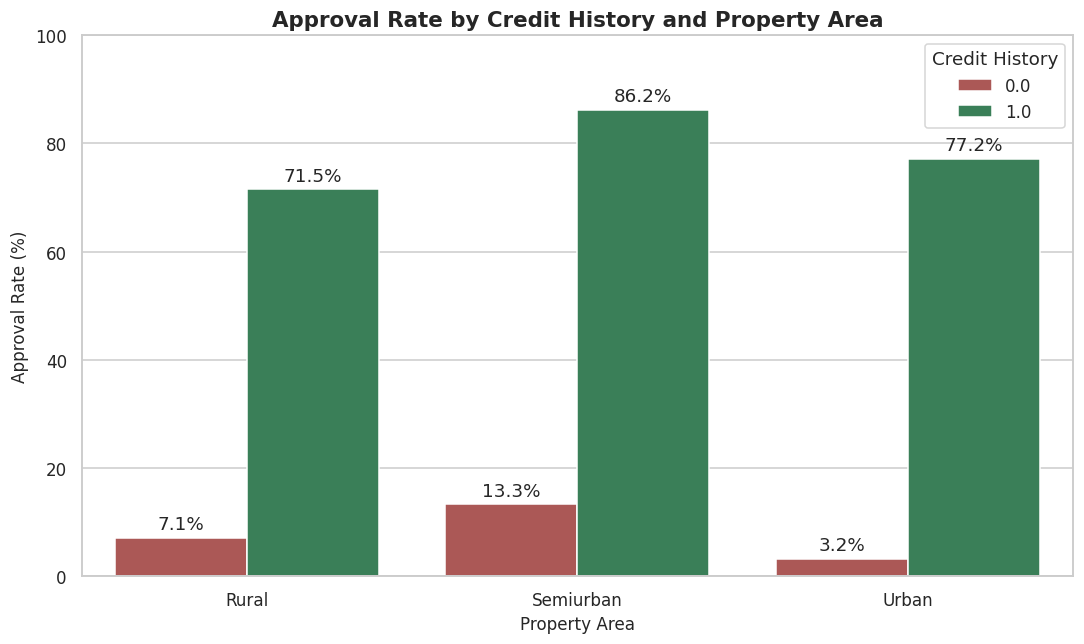

In [38]:
combined_approval = (
    loan_df.groupby(["credit_history", "property_area"])
    .agg(applications=("approved", "size"), approval_rate=("approved", "mean"))
    .reset_index()
)
combined_approval["approval_rate_percentage"] = combined_approval["approval_rate"] * 100
display(combined_approval.round(2))

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=combined_approval,
    x="property_area",
    y="approval_rate_percentage",
    hue="credit_history",
    palette=["#B94A48", "#2E8B57"],
)
plt.title("Approval Rate by Credit History and Property Area", fontweight="bold")
plt.xlabel("Property Area")
plt.ylabel("Approval Rate (%)")
plt.ylim(0, 100)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
plt.legend(title="Credit History")
plt.tight_layout()
plt.show()


## Part 2 conclusion

The advanced EDA produced more than the required 20 visualizations. Credit history shows the clearest relationship with approval, while financial variables overlap substantially across outcomes. Property area, education and marital status show smaller descriptive differences. Income and loan amount are strongly related to one another, but neither appears to separate approvals from rejections independently. Formal testing is required before these patterns are treated as statistically supported.


# Part 3 — Statistical Analysis

Statistical testing evaluates whether the differences observed during EDA are likely to reflect systematic relationships rather than random sample variation. The significance level is set at 5% (`alpha = 0.05`). Because the financial variables are strongly skewed and contain extreme observations, rank-based nonparametric tests are used for group comparisons.


## 3.1 Import statistical tools and assess assumptions


In [39]:
from scipy import stats

ALPHA = 0.05

assumption_rows = []
for column in ["applicant_income", "coapplicant_income", "loan_amount", "total_income", "loan_income_ratio"]:
    shapiro_stat, shapiro_p = stats.shapiro(loan_df[column])
    approved_values = loan_df.loc[loan_df["loan_status"] == "Y", column]
    rejected_values = loan_df.loc[loan_df["loan_status"] == "N", column]
    levene_stat, levene_p = stats.levene(approved_values, rejected_values, center="median")
    assumption_rows.append({
        "feature": column,
        "shapiro_statistic": shapiro_stat,
        "shapiro_p_value": shapiro_p,
        "levene_statistic": levene_stat,
        "levene_p_value": levene_p,
    })

assumption_table = pd.DataFrame(assumption_rows)
display(assumption_table.round(6))


              feature  shapiro_statistic  shapiro_p_value  levene_statistic  \
0    applicant_income              0.471            0.000             0.041   
1  coapplicant_income              0.482            0.000             4.880   
2         loan_amount              0.760            0.000             0.493   
3        total_income              0.525            0.000             1.672   
4   loan_income_ratio              0.916            0.000             6.823   

   levene_p_value  
0           0.839  
1           0.028  
2           0.483  
3           0.197  
4           0.009  


Shapiro–Wilk results support the EDA finding that the financial variables are not normally distributed. Mann–Whitney U and Kruskal–Wallis tests are therefore preferred for numerical comparisons. Chi-square tests are used for categorical relationships.


## 3.2 Statistical testing functions


In [40]:
statistical_results = []


def chi_square_analysis(data, feature, target="loan_status"):
    contingency = pd.crosstab(data[feature], data[target])
    chi2, p_value, degrees_freedom, expected = stats.chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    rows, columns = contingency.shape
    cramers_v = np.sqrt((chi2 / n) / min(rows - 1, columns - 1))
    conclusion = "Reject H0" if p_value < ALPHA else "Fail to reject H0"
    statistical_results.append({
        "analysis": f"Chi-square: {feature} vs {target}",
        "statistic": chi2,
        "p_value": p_value,
        "effect_size": cramers_v,
        "conclusion": conclusion,
    })
    print(f"Objective: Determine whether {feature} is associated with {target}.")
    print(f"H0: {feature} and {target} are independent.")
    print(f"H1: {feature} and {target} are associated.")
    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"Degrees of freedom: {degrees_freedom}")
    print(f"P-value: {p_value:.6g}")
    print(f"Cramer's V: {cramers_v:.4f}")
    print(f"Minimum expected count: {expected.min():.2f}")
    print(f"Decision: {conclusion}")
    display(contingency)


def mann_whitney_analysis(data, feature):
    approved_group = data.loc[data["loan_status"] == "Y", feature]
    rejected_group = data.loc[data["loan_status"] == "N", feature]
    statistic, p_value = stats.mannwhitneyu(
        approved_group,
        rejected_group,
        alternative="two-sided",
    )
    rank_biserial = 1 - (2 * statistic) / (len(approved_group) * len(rejected_group))
    conclusion = "Reject H0" if p_value < ALPHA else "Fail to reject H0"
    statistical_results.append({
        "analysis": f"Mann-Whitney U: {feature} by loan_status",
        "statistic": statistic,
        "p_value": p_value,
        "effect_size": rank_biserial,
        "conclusion": conclusion,
    })
    print(f"Objective: Compare the distribution of {feature} across approval outcomes.")
    print(f"H0: The {feature} distributions are equal across approval outcomes.")
    print(f"H1: The {feature} distributions differ across approval outcomes.")
    print(f"U statistic: {statistic:.4f}")
    print(f"P-value: {p_value:.6g}")
    print(f"Rank-biserial effect size: {rank_biserial:.4f}")
    print(f"Decision: {conclusion}")


## 3.3 Test 1 — Credit history and loan approval


In [41]:
chi_square_analysis(loan_df, "credit_history")


Objective: Determine whether credit_history is associated with loan_status.
H0: credit_history and loan_status are independent.
H1: credit_history and loan_status are associated.
Chi-square statistic: 176.1146
Degrees of freedom: 1
P-value: 3.41835e-40
Cramer's V: 0.5356
Minimum expected count: 27.83
Decision: Reject H0
loan_status       N    Y
credit_history          
0.000            82    7
1.000           110  415


The null hypothesis is rejected. Credit history has a statistically significant association with loan approval (`p < 0.001`) and a comparatively strong Cramér’s V of approximately 0.536. In business terms, credit history is the clearest observed approval factor in this dataset. This does not prove causation, but it strongly supports retaining credit history for modelling.


## 3.4 Test 2 — Property area and loan approval


In [42]:
chi_square_analysis(loan_df, "property_area")


Objective: Determine whether property_area is associated with loan_status.
H0: property_area and loan_status are independent.
H1: property_area and loan_status are associated.
Chi-square statistic: 12.2976
Degrees of freedom: 2
P-value: 0.00213602
Cramer's V: 0.1415
Minimum expected count: 55.97
Decision: Reject H0
loan_status     N    Y
property_area         
Rural          69  110
Semiurban      54  179
Urban          69  133


The null hypothesis is rejected (`p ≈ 0.002`). Property area is associated with approval, although Cramér’s V of approximately 0.142 indicates a much weaker relationship than credit history. Geographic information may contribute incremental predictive value but should not be treated as the dominant factor.


## 3.5 Test 3 — Total income by approval outcome


In [43]:
mann_whitney_analysis(loan_df, "total_income")


Objective: Compare the distribution of total_income across approval outcomes.
H0: The total_income distributions are equal across approval outcomes.
H1: The total_income distributions differ across approval outcomes.
U statistic: 41262.5000
P-value: 0.712835
Rank-biserial effect size: -0.0185
Decision: Fail to reject H0


The test fails to reject the null hypothesis (`p ≈ 0.713`). Total-income distributions do not differ significantly between approved and rejected applications. Income may still interact with requested loan size or other characteristics, but it does not independently separate the outcomes in this sample.


## 3.6 Test 4 — Loan amount by approval outcome


In [44]:
mann_whitney_analysis(loan_df, "loan_amount")


Objective: Compare the distribution of loan_amount across approval outcomes.
H0: The loan_amount distributions are equal across approval outcomes.
H1: The loan_amount distributions differ across approval outcomes.
U statistic: 38788.0000
P-value: 0.397606
Rank-biserial effect size: 0.0426
Decision: Fail to reject H0


The test fails to reject the null hypothesis (`p ≈ 0.398`). Requested loan amounts do not differ significantly between approved and rejected groups. Loan size should be interpreted in relation to income, repayment period and credit history rather than in isolation.


## 3.7 Test 5 — Total income across property areas


In [45]:
income_groups = [
    group["total_income"].to_numpy()
    for _, group in loan_df.groupby("property_area")
]

kruskal_statistic, kruskal_p = stats.kruskal(*income_groups)
kruskal_conclusion = "Reject H0" if kruskal_p < ALPHA else "Fail to reject H0"
statistical_results.append({
    "analysis": "Kruskal-Wallis: total_income by property_area",
    "statistic": kruskal_statistic,
    "p_value": kruskal_p,
    "effect_size": np.nan,
    "conclusion": kruskal_conclusion,
})

print("Objective: Determine whether total-income distributions differ across property areas.")
print("H0: All property areas have the same total-income distribution.")
print("H1: At least one property area has a different total-income distribution.")
print(f"H statistic: {kruskal_statistic:.4f}")
print(f"P-value: {kruskal_p:.6g}")
print(f"Decision: {kruskal_conclusion}")


Objective: Determine whether total-income distributions differ across property areas.
H0: All property areas have the same total-income distribution.
H1: At least one property area has a different total-income distribution.
H statistic: 3.9326
P-value: 0.139977
Decision: Fail to reject H0


The test fails to reject the null hypothesis (`p ≈ 0.140`). The available evidence does not show a significant difference in total-income distributions across rural, urban and semiurban applicants. The property-area approval relationship therefore cannot be explained simply by total-income differences.


## 3.8 Test 6 — Total income and loan amount correlation


In [46]:
spearman_rho, spearman_p = stats.spearmanr(
    loan_df["total_income"],
    loan_df["loan_amount"],
)
spearman_conclusion = "Reject H0" if spearman_p < ALPHA else "Fail to reject H0"
statistical_results.append({
    "analysis": "Spearman: total_income vs loan_amount",
    "statistic": spearman_rho,
    "p_value": spearman_p,
    "effect_size": spearman_rho,
    "conclusion": spearman_conclusion,
})

print("Objective: Test whether total income and requested loan amount are monotonically related.")
print("H0: There is no monotonic relationship between total income and loan amount.")
print("H1: A monotonic relationship exists between total income and loan amount.")
print(f"Spearman rho: {spearman_rho:.4f}")
print(f"P-value: {spearman_p:.6g}")
print(f"Decision: {spearman_conclusion}")


Objective: Test whether total income and requested loan amount are monotonically related.
H0: There is no monotonic relationship between total income and loan amount.
H1: A monotonic relationship exists between total income and loan amount.
Spearman rho: 0.6878
P-value: 3.42268e-87
Decision: Reject H0


The null hypothesis is rejected (`p < 0.001`). Total income and loan amount have a strong positive monotonic relationship (`ρ ≈ 0.688`): applicants with higher household income generally request larger loans. This relationship does not imply that either feature independently determines approval.


## 3.9 Statistical results summary


In [47]:
statistical_results_df = pd.DataFrame(statistical_results)
display(statistical_results_df.round(6))


                                        analysis  statistic  p_value  \
0      Chi-square: credit_history vs loan_status    176.115    0.000   
1       Chi-square: property_area vs loan_status     12.298    0.002   
2    Mann-Whitney U: total_income by loan_status 41,262.500    0.713   
3     Mann-Whitney U: loan_amount by loan_status 38,788.000    0.398   
4  Kruskal-Wallis: total_income by property_area      3.933    0.140   
5          Spearman: total_income vs loan_amount      0.688    0.000   

   effect_size         conclusion  
0        0.536          Reject H0  
1        0.142          Reject H0  
2       -0.019  Fail to reject H0  
3        0.043  Fail to reject H0  
4          NaN  Fail to reject H0  
5        0.688          Reject H0  


## Part 3 conclusion

The strongest statistically supported approval relationship is credit history. Property area also has a significant but weaker association. Total income and loan amount do not differ significantly by approval outcome, while total income and requested loan amount are strongly related to one another. These findings support a feature strategy that prioritizes credit information and affordability relationships rather than raw financial values alone.


# Part 4 — Feature Engineering

Feature engineering converts existing fields into representations that better reflect household structure, income composition, repayment burden and model-friendly distributions. Every engineered feature is treated as a candidate; Part 5 determines whether it should be retained.


## 4.1 Create engineered features


In [48]:
engineered_df = loan_df.copy()

# 1. Numeric dependents: "3+" is represented conservatively as 3.
engineered_df["dependents_numeric"] = (
    engineered_df["dependents"].replace({"3+": 3}).astype(int)
)

# 2. Approximate family size: applicant + spouse if married + dependents.
engineered_df["family_size"] = (
    1
    + engineered_df["married"].eq("Yes").astype(int)
    + engineered_df["dependents_numeric"]
)

# 3. Interpretable household-size category.
engineered_df["family_size_group"] = pd.cut(
    engineered_df["family_size"],
    bins=[0, 2, 4, np.inf],
    labels=["Small", "Medium", "Large"],
)

# 4. Fixed income bands based on observed distribution ranges.
engineered_df["income_band"] = pd.cut(
    engineered_df["total_income"],
    bins=[-np.inf, 4000, 7000, 12000, np.inf],
    labels=["Low", "Middle", "High", "Very High"],
)

# 5. Whether the household reports coapplicant income.
engineered_df["has_coapplicant_income"] = (
    engineered_df["coapplicant_income"] > 0
).astype(int)

# 6. Proportion of household income contributed by the coapplicant.
engineered_df["coapplicant_income_share"] = np.where(
    engineered_df["total_income"] > 0,
    engineered_df["coapplicant_income"] / engineered_df["total_income"],
    0,
)

# 7. Loan duration in years.
engineered_df["term_years"] = engineered_df["loan_amount_term"] / 12

# 8. Estimated monthly principal. LoanAmount is recorded in thousands.
engineered_df["estimated_monthly_principal"] = (
    engineered_df["loan_amount"] * 1000
) / engineered_df["loan_amount_term"]

# 9. Repayment burden proxy. This excludes interest and existing debt.
engineered_df["payment_income_ratio"] = (
    engineered_df["estimated_monthly_principal"]
    / engineered_df["total_income"]
)

# 10. Business-readable credit category.
engineered_df["credit_risk_category"] = engineered_df["credit_history"].map({
    1.0: "Positive Credit History",
    0.0: "Higher Credit Risk",
})

# 11–12. Model-friendly transformations of skewed financial features.
engineered_df["log_total_income"] = np.log1p(engineered_df["total_income"])
engineered_df["log_loan_amount"] = np.log1p(engineered_df["loan_amount"])

engineered_columns = [
    "dependents_numeric",
    "family_size",
    "family_size_group",
    "income_band",
    "has_coapplicant_income",
    "coapplicant_income_share",
    "term_years",
    "estimated_monthly_principal",
    "payment_income_ratio",
    "credit_risk_category",
    "log_total_income",
    "log_loan_amount",
]

display(engineered_df[engineered_columns].head())


   dependents_numeric  family_size family_size_group income_band  \
0                   0            1             Small      Middle   
1                   1            3            Medium      Middle   
2                   0            2             Small         Low   
3                   0            2             Small      Middle   
4                   0            1             Small      Middle   

   has_coapplicant_income  coapplicant_income_share  term_years  \
0                       0                     0.000      30.000   
1                       1                     0.248      30.000   
2                       0                     0.000      30.000   
3                       1                     0.477      30.000   
4                       0                     0.000      30.000   

   estimated_monthly_principal  payment_income_ratio     credit_risk_category  \
0                      355.556                 0.061  Positive Credit History   
1                      355

## 4.2 Feature-engineering documentation


In [49]:
feature_engineering_documentation = pd.DataFrame([
    ["dependents_numeric", "Converts 3+ to a conservative numeric value of 3", "Supports ordinal and household calculations", "Numerical input for models"],
    ["family_size", "Approximates applicant, spouse and dependents", "Represents household responsibility", "Potential nonlinear household effect"],
    ["family_size_group", "Segments household size", "Provides interpretable customer groups", "Captures nonlinear category effects"],
    ["income_band", "Groups household income using fixed thresholds", "Supports customer segmentation", "Captures nonlinear income effects"],
    ["has_coapplicant_income", "Flags positive coapplicant income", "Distinguishes single- and dual-income applications", "Adds a stable binary signal"],
    ["coapplicant_income_share", "Measures coapplicant contribution to household income", "Shows reliance on shared income", "More informative than coapplicant income alone"],
    ["term_years", "Converts months into years", "Easier business interpretation", "Equivalent scale with clearer meaning"],
    ["estimated_monthly_principal", "Loan principal divided by term", "Approximates monthly repayment before interest", "Combines loan size and duration"],
    ["payment_income_ratio", "Estimated monthly principal divided by income", "Affordability proxy", "Combines income, amount and term"],
    ["credit_risk_category", "Readable category from credit history", "Communicates risk clearly", "Useful for reporting; redundant for modelling"],
    ["log_total_income", "Log transform of total income", "Reduces dominance of extreme incomes", "Improves linear-model behaviour"],
    ["log_loan_amount", "Log transform of loan amount", "Reduces dominance of large loans", "Improves linear-model behaviour"],
], columns=["feature", "creation_reason", "business_value", "modelling_benefit"])

display(feature_engineering_documentation)


                        feature  \
0            dependents_numeric   
1                   family_size   
2             family_size_group   
3                   income_band   
4        has_coapplicant_income   
5      coapplicant_income_share   
6                    term_years   
7   estimated_monthly_principal   
8          payment_income_ratio   
9          credit_risk_category   
10             log_total_income   
11              log_loan_amount   

                                      creation_reason  \
0    Converts 3+ to a conservative numeric value of 3   
1       Approximates applicant, spouse and dependents   
2                             Segments household size   
3      Groups household income using fixed thresholds   
4                   Flags positive coapplicant income   
5   Measures coapplicant contribution to household...   
6                          Converts months into years   
7                      Loan principal divided by term   
8       Estimated monthly princ

### Affordability limitation

`payment_income_ratio` is a repayment-burden proxy, not a true debt-to-income ratio. The dataset does not provide interest rate, existing debt obligations, fees or verified monthly repayments. The variable should therefore support modelling and screening analysis, not be interpreted as a complete affordability assessment.


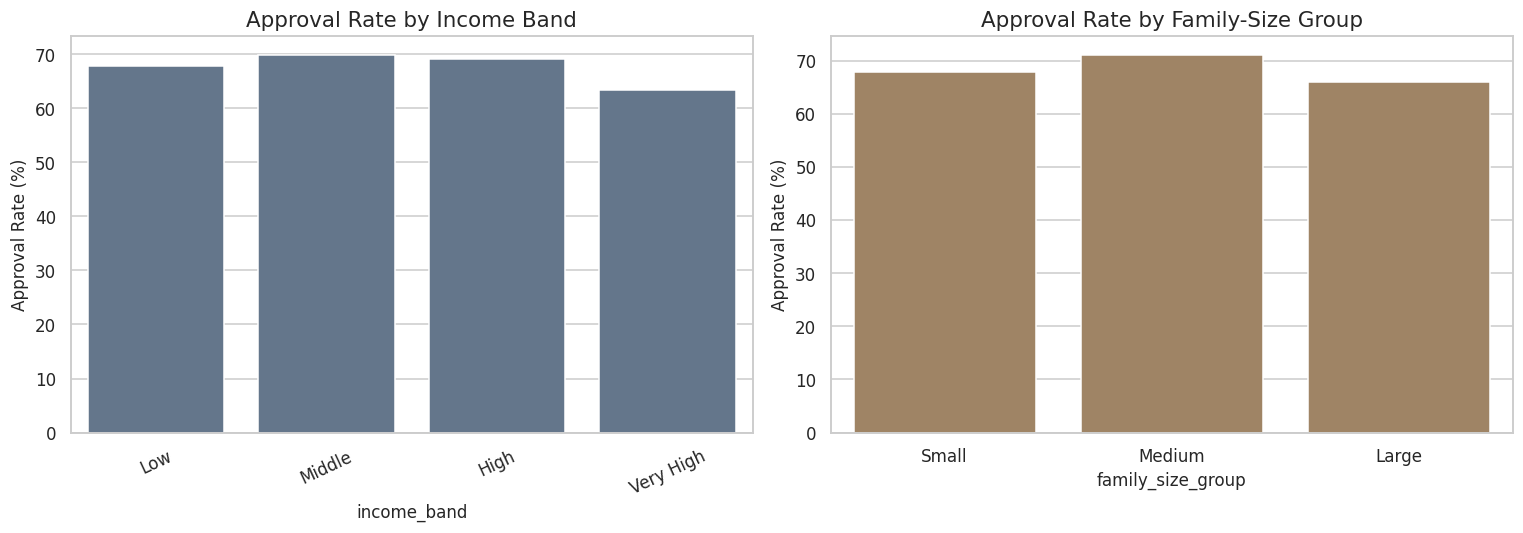

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

income_rate = approval_rate_table(engineered_df, "income_band")
sns.barplot(data=income_rate, x="income_band", y="approval_rate_percentage", ax=axes[0], color="#5E7691")
axes[0].set_title("Approval Rate by Income Band")
axes[0].set_ylabel("Approval Rate (%)")
axes[0].tick_params(axis="x", rotation=25)

family_rate = approval_rate_table(engineered_df, "family_size_group")
sns.barplot(data=family_rate, x="family_size_group", y="approval_rate_percentage", ax=axes[1], color="#A9855B")
axes[1].set_title("Approval Rate by Family-Size Group")
axes[1].set_ylabel("Approval Rate (%)")

plt.tight_layout()
plt.show()


# Part 5 — Feature Selection

Feature selection balances predictive information, statistical evidence, redundancy, interpretability, leakage risk and responsible use. Creating a feature does not guarantee that it should be included in the final model.


## 5.1 Correlation and redundancy assessment


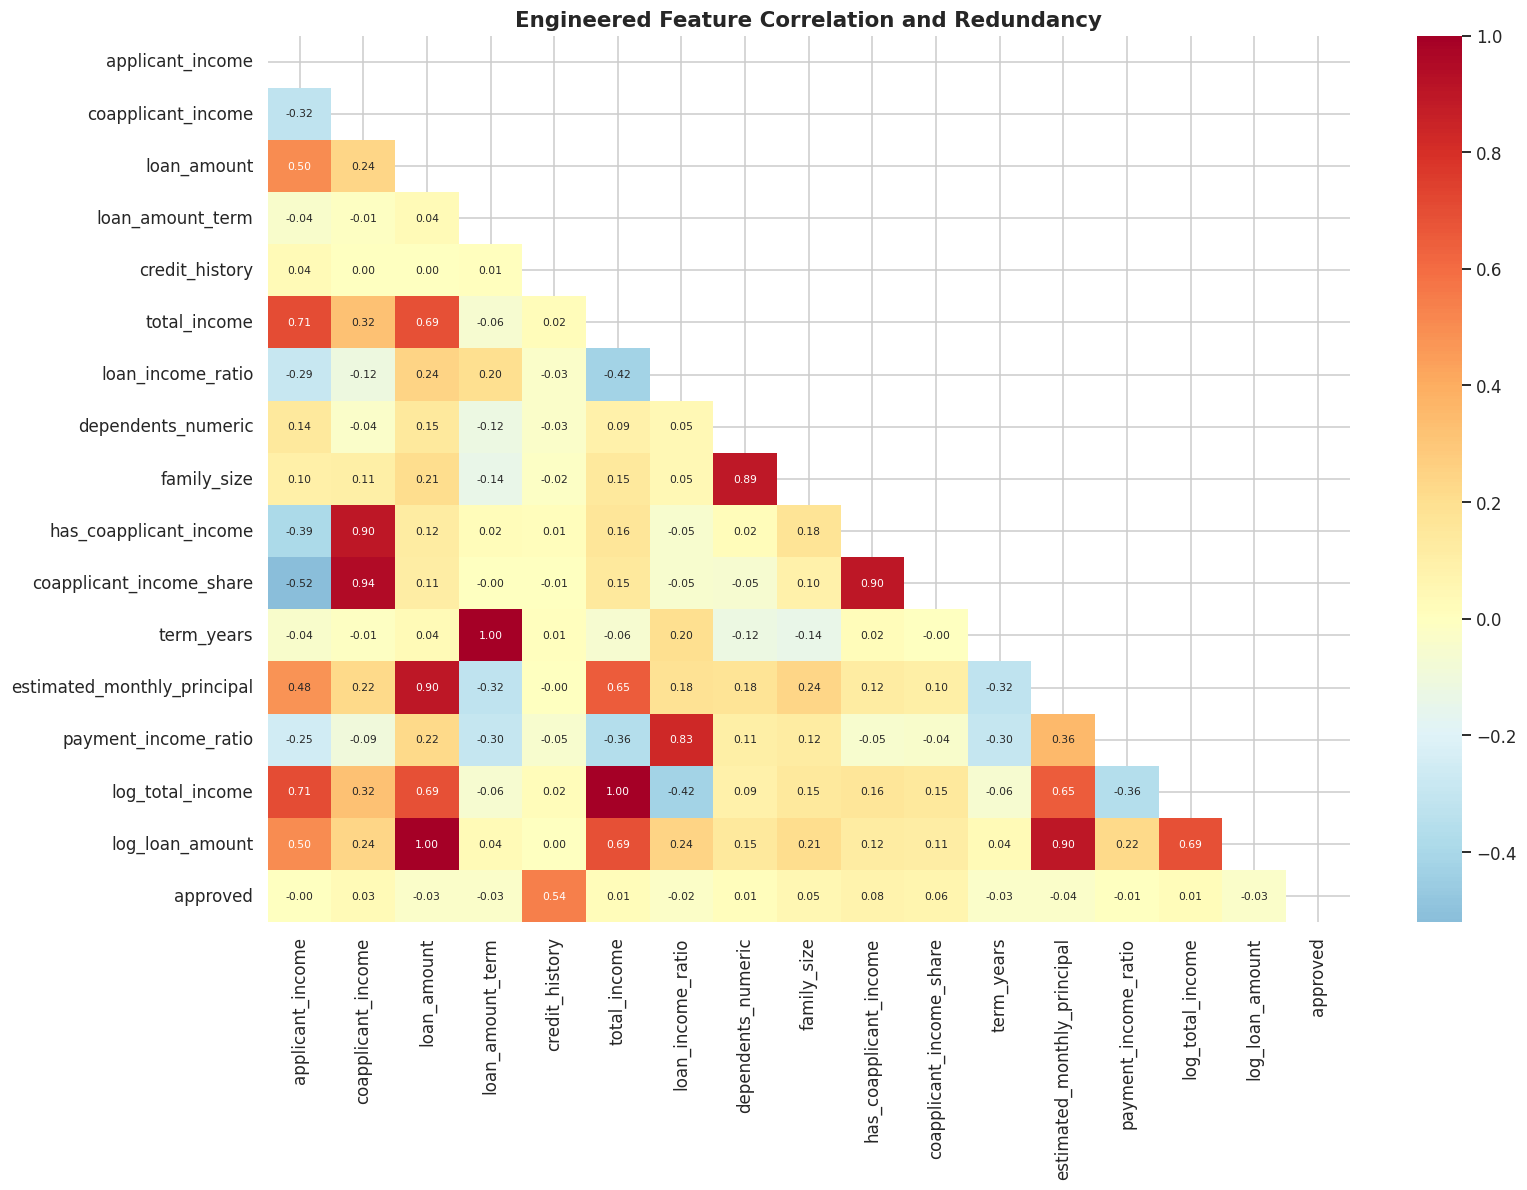

In [51]:
selection_numeric_features = [
    "applicant_income",
    "coapplicant_income",
    "loan_amount",
    "loan_amount_term",
    "credit_history",
    "total_income",
    "loan_income_ratio",
    "dependents_numeric",
    "family_size",
    "has_coapplicant_income",
    "coapplicant_income_share",
    "term_years",
    "estimated_monthly_principal",
    "payment_income_ratio",
    "log_total_income",
    "log_loan_amount",
    "approved",
]

selection_correlation = engineered_df[selection_numeric_features].corr(method="spearman")

plt.figure(figsize=(15, 11))
mask = np.triu(np.ones_like(selection_correlation, dtype=bool))
sns.heatmap(
    selection_correlation,
    mask=mask,
    cmap="RdYlBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
)
plt.title("Engineered Feature Correlation and Redundancy", fontweight="bold")
plt.tight_layout()
plt.show()


Expected redundancies include applicant income with total income, loan term in months with term in years, credit history with its readable category, and raw financial values with their logarithmic transformations. These relationships are expected because one variable is directly derived from another.


## 5.2 Mutual-information screening


In [52]:
from sklearn.feature_selection import mutual_info_classif

mi_features = [
    "gender",
    "married",
    "dependents_numeric",
    "education",
    "self_employed",
    "property_area",
    "credit_history",
    "log_total_income",
    "log_loan_amount",
    "term_years",
    "has_coapplicant_income",
    "coapplicant_income_share",
    "payment_income_ratio",
]

mi_source = engineered_df[mi_features].copy()
mi_encoded = pd.get_dummies(
    mi_source,
    columns=["gender", "married", "education", "self_employed", "property_area"],
    dtype=int,
)

discrete_prefixes = ("gender_", "married_", "education_", "self_employed_", "property_area_")
discrete_names = {"dependents_numeric", "credit_history", "has_coapplicant_income"}
discrete_mask = np.array([
    column.startswith(discrete_prefixes) or column in discrete_names
    for column in mi_encoded.columns
])

mi_scores = mutual_info_classif(
    mi_encoded,
    engineered_df["approved"],
    discrete_features=discrete_mask,
    random_state=RANDOM_STATE,
)

mutual_information_table = (
    pd.DataFrame({"feature": mi_encoded.columns, "mutual_information": mi_scores})
    .sort_values("mutual_information", ascending=False)
    .reset_index(drop=True)
)

display(mutual_information_table.round(4))


                     feature  mutual_information
0             credit_history               0.142
1    property_area_Semiurban               0.010
2   coapplicant_income_share               0.006
3        property_area_Rural               0.005
4                 married_No               0.004
5                married_Yes               0.004
6         education_Graduate               0.004
7     education_Not Graduate               0.004
8     has_coapplicant_income               0.003
9         dependents_numeric               0.003
10       property_area_Urban               0.001
11               gender_Male               0.000
12             gender_Female               0.000
13         self_employed_Yes               0.000
14          self_employed_No               0.000
15          log_total_income               0.000
16      payment_income_ratio               0.000
17                term_years               0.000
18           log_loan_amount               0.000


Mutual information is used as supporting evidence rather than proof of causation. It can detect nonlinear dependence, but scores may vary with sample size and encoding. Credit history is expected to dominate, consistent with EDA and hypothesis testing.


## 5.3 Final feature decisions


In [53]:
feature_selection_decisions = pd.DataFrame([
    ["gender", "Remove from predictive inputs", "Protected characteristic; retain only for fairness auditing"],
    ["married", "Select", "Small significant association and possible household context"],
    ["dependents", "Replace", "Use dependents_numeric for machine-readable ordinal information"],
    ["dependents_numeric", "Select", "Compact ordinal representation"],
    ["education", "Select", "Weak but statistically significant association"],
    ["self_employed", "Select with caution", "Low univariate association but may interact with other features"],
    ["property_area", "Select", "Statistically significant categorical association"],
    ["credit_history", "Select", "Strongest statistical and predictive evidence"],
    ["applicant_income", "Remove", "Redundant with total income and coapplicant share representation"],
    ["coapplicant_income", "Remove", "Represented by total income, binary flag and income share"],
    ["total_income", "Replace", "Use log_total_income to reduce skewness"],
    ["loan_amount", "Replace", "Use log_loan_amount to reduce skewness"],
    ["loan_amount_term", "Replace", "Use term_years for clearer scale"],
    ["loan_income_ratio", "Remove", "Original unit interpretation is inconsistent"],
    ["family_size", "Remove from final model", "Exact derivation from married status and dependents"],
    ["family_size_group", "Reporting only", "Interpretable but redundant with household inputs"],
    ["income_band", "Reporting only", "Interpretable but discards continuous income detail"],
    ["has_coapplicant_income", "Select", "Stable household-income composition signal"],
    ["coapplicant_income_share", "Select", "Measures reliance on coapplicant income"],
    ["term_years", "Select", "Readable loan duration"],
    ["estimated_monthly_principal", "Remove from final model", "Components are represented in burden ratio and transformed loan amount"],
    ["payment_income_ratio", "Select", "Affordability proxy combining amount, income and term"],
    ["credit_risk_category", "Reporting only", "Exact duplicate of credit_history"],
    ["log_total_income", "Select", "Reduced-skew income representation"],
    ["log_loan_amount", "Select", "Reduced-skew loan representation"],
], columns=["feature", "decision", "justification"])

display(feature_selection_decisions)


                        feature                       decision  \
0                        gender  Remove from predictive inputs   
1                       married                         Select   
2                    dependents                        Replace   
3            dependents_numeric                         Select   
4                     education                         Select   
5                 self_employed            Select with caution   
6                 property_area                         Select   
7                credit_history                         Select   
8              applicant_income                         Remove   
9            coapplicant_income                         Remove   
10                 total_income                        Replace   
11                  loan_amount                        Replace   
12             loan_amount_term                        Replace   
13            loan_income_ratio                         Remove   
14        

In [54]:
final_selected_features = [
    "married",
    "dependents_numeric",
    "education",
    "self_employed",
    "property_area",
    "credit_history",
    "log_total_income",
    "log_loan_amount",
    "term_years",
    "has_coapplicant_income",
    "coapplicant_income_share",
    "payment_income_ratio",
]

print(f"Selected modelling features: {len(final_selected_features)}")
for feature in final_selected_features:
    print(f"- {feature}")


Selected modelling features: 12
- married
- dependents_numeric
- education
- self_employed
- property_area
- credit_history
- log_total_income
- log_loan_amount
- term_years
- has_coapplicant_income
- coapplicant_income_share
- payment_income_ratio


## Responsible feature-use decision

Gender remains in the final analytical dataset so that approval outcomes and future model predictions can be audited for fairness. It is excluded from predictive inputs because using a protected characteristic in automated lending decisions can reproduce or amplify historical bias. Regulatory requirements differ by jurisdiction; deployment would require legal and governance review.


# Part 6 — Data Preparation for Machine Learning

The data is split before preprocessing. The one-hot encoder and standard scaler are fitted on the training partition only, preventing information from the test set from influencing preprocessing parameters.


## 6.1 Train-test split


In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = engineered_df[final_selected_features].copy()
y = engineered_df["approved"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training observations: {len(X_train)}")
print(f"Testing observations: {len(X_test)}")
print(f"Training approval rate: {y_train.mean():.3%}")
print(f"Testing approval rate: {y_test.mean():.3%}")


Training observations: 491
Testing observations: 123
Training approval rate: 68.635%
Testing approval rate: 69.106%


## 6.2 Encoding and scaling pipeline


In [56]:
nominal_features = [
    "married",
    "education",
    "self_employed",
    "property_area",
]

continuous_model_features = [
    "log_total_income",
    "log_loan_amount",
    "term_years",
    "coapplicant_income_share",
    "payment_income_ratio",
]

passthrough_features = [
    "dependents_numeric",
    "credit_history",
    "has_coapplicant_income",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
            nominal_features,
        ),
        ("continuous", StandardScaler(), continuous_model_features),
        ("binary_ordinal", "passthrough", passthrough_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
transformed_feature_names = preprocessor.get_feature_names_out()

X_train_ready = pd.DataFrame(
    X_train_transformed,
    columns=transformed_feature_names,
    index=X_train.index,
)
X_test_ready = pd.DataFrame(
    X_test_transformed,
    columns=transformed_feature_names,
    index=X_test.index,
)

print(f"Transformed feature count: {len(transformed_feature_names)}")
display(X_train_ready.head())


Transformed feature count: 13
     married_Yes  education_Not Graduate  self_employed_Yes  \
154        0.000                   0.000              0.000   
239        1.000                   0.000              0.000   
448        1.000                   0.000              0.000   
471        1.000                   1.000              0.000   
273        1.000                   0.000              0.000   

     property_area_Semiurban  property_area_Urban  log_total_income  \
154                    0.000                1.000            -1.087   
239                    1.000                0.000            -1.053   
448                    0.000                0.000            -0.278   
471                    0.000                0.000            -0.638   
273                    1.000                0.000            -0.355   

     log_loan_amount  term_years  coapplicant_income_share  \
154           -1.896       0.281                    -0.947   
239           -0.596       0.281        

## 6.3 Assemble and export final datasets


In [57]:
train_ml_ready = X_train_ready.copy()
train_ml_ready["approved"] = y_train

test_ml_ready = X_test_ready.copy()
test_ml_ready["approved"] = y_test

train_export = train_ml_ready.reset_index(drop=True)
train_export["dataset_split"] = "train"

test_export = test_ml_ready.reset_index(drop=True)
test_export["dataset_split"] = "test"

ml_ready_combined = pd.concat([train_export, test_export], ignore_index=True)

# The final cleaned file remains human-readable and includes engineered fields.
final_cleaned_dataset = engineered_df.drop(columns=["approved"]).copy()

final_cleaned_path = OUTPUT_DIR / "loan_prediction_week3_final_cleaned.csv"
ml_ready_path = OUTPUT_DIR / "loan_prediction_week3_ml_ready.csv"
train_path = OUTPUT_DIR / "loan_prediction_week3_train.csv"
test_path = OUTPUT_DIR / "loan_prediction_week3_test.csv"

final_cleaned_dataset.to_csv(final_cleaned_path, index=False)
ml_ready_combined.to_csv(ml_ready_path, index=False)
train_export.to_csv(train_path, index=False)
test_export.to_csv(test_path, index=False)

print(f"Saved: {final_cleaned_path}")
print(f"Saved: {ml_ready_path}")
print(f"Saved: {train_path}")
print(f"Saved: {test_path}")


Saved: week3_outputs/loan_prediction_week3_final_cleaned.csv
Saved: week3_outputs/loan_prediction_week3_ml_ready.csv
Saved: week3_outputs/loan_prediction_week3_train.csv
Saved: week3_outputs/loan_prediction_week3_test.csv


The combined ML-ready file contains a `dataset_split` column. Week 4 modelling must train only on rows marked `train` and evaluate only on rows marked `test`. The split marker is metadata and must not be passed into a model as a predictor.


## 6.4 Updated data dictionary


In [58]:
dictionary_rows = []

for feature in engineered_df.drop(columns=["approved"]).columns:
    role = "Target" if feature == "loan_status" else "Analytical feature"
    description = {
        "loan_status": "Original loan approval outcome: Y or N",
        "total_income": "Applicant plus coapplicant monthly income",
        "loan_income_ratio": "Original Week 2 ratio; retained for audit but not selected for modelling",
        "dependents_numeric": "Dependents converted to a conservative numeric value",
        "family_size": "Applicant plus spouse if married plus dependents",
        "family_size_group": "Small, medium or large approximate household",
        "income_band": "Fixed total-income segment",
        "has_coapplicant_income": "1 when coapplicant income is greater than zero",
        "coapplicant_income_share": "Coapplicant income divided by total income",
        "term_years": "Loan repayment term expressed in years",
        "estimated_monthly_principal": "Loan principal divided by term; excludes interest",
        "payment_income_ratio": "Estimated monthly principal divided by household income",
        "credit_risk_category": "Readable category derived from credit history",
        "log_total_income": "Natural log of one plus total income",
        "log_loan_amount": "Natural log of one plus loan amount",
    }.get(feature, feature.replace("_", " ").title())

    dictionary_rows.append({
        "dataset": "final_cleaned",
        "feature": feature,
        "data_type": str(engineered_df[feature].dtype),
        "role": role,
        "description": description,
    })

for feature in transformed_feature_names:
    dictionary_rows.append({
        "dataset": "ml_ready",
        "feature": feature,
        "data_type": "float",
        "role": "Predictor",
        "description": "Encoded, scaled or passthrough modelling feature produced by the training-fitted preprocessing pipeline",
    })

dictionary_rows.extend([
    {
        "dataset": "ml_ready",
        "feature": "approved",
        "data_type": "integer",
        "role": "Target",
        "description": "1 for approved and 0 for rejected",
    },
    {
        "dataset": "ml_ready",
        "feature": "dataset_split",
        "data_type": "string",
        "role": "Metadata",
        "description": "Predetermined train or test partition; exclude from model inputs",
    },
])

updated_data_dictionary = pd.DataFrame(dictionary_rows)
data_dictionary_path = OUTPUT_DIR / "week3_updated_data_dictionary.csv"
updated_data_dictionary.to_csv(data_dictionary_path, index=False)

display(updated_data_dictionary.head(20))
print(f"Saved: {data_dictionary_path}")


          dataset                   feature data_type                role  \
0   final_cleaned                    gender    object  Analytical feature   
1   final_cleaned                   married    object  Analytical feature   
2   final_cleaned                dependents    object  Analytical feature   
3   final_cleaned                 education    object  Analytical feature   
4   final_cleaned             self_employed    object  Analytical feature   
5   final_cleaned          applicant_income     int64  Analytical feature   
6   final_cleaned        coapplicant_income   float64  Analytical feature   
7   final_cleaned               loan_amount   float64  Analytical feature   
8   final_cleaned          loan_amount_term   float64  Analytical feature   
9   final_cleaned            credit_history   float64  Analytical feature   
10  final_cleaned             property_area    object  Analytical feature   
11  final_cleaned               loan_status    object              Target   

## 6.5 Final validation


In [59]:
validation_summary = pd.DataFrame([
    {
        "dataset": "final_cleaned",
        "rows": final_cleaned_dataset.shape[0],
        "columns": final_cleaned_dataset.shape[1],
        "missing_values": final_cleaned_dataset.isna().sum().sum(),
        "duplicate_rows": final_cleaned_dataset.duplicated().sum(),
    },
    {
        "dataset": "train_ml_ready",
        "rows": train_export.shape[0],
        "columns": train_export.shape[1],
        "missing_values": train_export.isna().sum().sum(),
        "duplicate_rows": train_export.duplicated().sum(),
    },
    {
        "dataset": "test_ml_ready",
        "rows": test_export.shape[0],
        "columns": test_export.shape[1],
        "missing_values": test_export.isna().sum().sum(),
        "duplicate_rows": test_export.duplicated().sum(),
    },
])

display(validation_summary)

assert final_cleaned_dataset.shape[0] == len(loan_df)
assert len(train_export) + len(test_export) == len(loan_df)
assert train_export.isna().sum().sum() == 0
assert test_export.isna().sum().sum() == 0
assert set(train_export["approved"].unique()).issubset({0, 1})
assert set(test_export["approved"].unique()).issubset({0, 1})

print("All final validation checks passed.")


          dataset  rows  columns  missing_values  duplicate_rows
0   final_cleaned   614       26               0               0
1  train_ml_ready   491       15               0               0
2   test_ml_ready   123       15               0               0
All final validation checks passed.


# Part 7 — Business Insights Report

## Executive summary

The analysis examined 614 historical loan applications, of which 422 (68.73%) were approved and 192 (31.27%) were rejected. The principal finding is that credit history has the clearest relationship with approval. Applicants with positive credit history recorded an approval rate of 79.05%, compared with 7.87% among applicants without positive credit history. The association is statistically significant and materially stronger than the other tested categorical relationships.

Property area is also associated with approval, but its effect is considerably smaller. Semiurban applicants recorded the highest approval rate at 76.82%, followed by urban applicants at 65.84% and rural applicants at 61.45%. This geographic pattern is not explained by significant total-income differences across property areas.

Raw income and loan size did not significantly differ between approved and rejected applications. However, total income and requested loan amount were strongly related, indicating that higher-income households generally requested larger loans. Affordability should therefore be evaluated through combined burden features rather than through income or loan amount alone.


## Key statistical findings

1. **Credit history and approval:** statistically significant with a strong relative effect (`χ² ≈ 176.11`, `p < 0.001`, Cramér’s V ≈ 0.536).
2. **Property area and approval:** statistically significant but weak (`χ² ≈ 12.30`, `p ≈ 0.002`, Cramér’s V ≈ 0.142).
3. **Total income by approval:** no significant distribution difference (`p ≈ 0.713`).
4. **Loan amount by approval:** no significant distribution difference (`p ≈ 0.398`).
5. **Income across property areas:** no significant distribution difference (`p ≈ 0.140`).
6. **Total income and loan amount:** strong positive monotonic relationship (`ρ ≈ 0.688`, `p < 0.001`).


## Business recommendations

1. **Prioritize verified credit information.** Credit history should remain a core input in the Week 4 model, subject to data-quality and governance controls.
2. **Use affordability relationships rather than raw income alone.** The engineered payment-income proxy combines requested amount, repayment term and household income. It should be improved with interest rates and verified debt obligations when such data becomes available.
3. **Investigate geographic differences.** The property-area association warrants deeper investigation into product mix, collateral valuation, branch policy and data-collection practices before operational decisions are made.
4. **Monitor fairness.** Gender was excluded from predictive inputs but retained for fairness auditing. Future models should compare error rates and approval recommendations across demographic groups.
5. **Evaluate beyond accuracy.** Because the target has moderate imbalance, Week 4 should report precision, recall, F1-score, ROC-AUC, PR-AUC and confusion matrices.
6. **Preserve preprocessing discipline.** Encoding and scaling must remain fitted on training data only and should be packaged in a reproducible pipeline for deployment.


## Dataset limitations

- The dataset contains only 614 applications, limiting the stability of small subgroup estimates.
- Missing values were imputed during Week 2, which may reduce natural variability.
- Credit history is binary and lacks detailed credit-score information.
- No interest rate, existing debt, verified monthly expenses or actual repayment amount is available.
- The data does not provide application dates, preventing temporal validation and drift analysis.
- The applicant identifier was removed, so repeated applicants cannot be independently identified.
- The target represents historical approval decisions, not loan repayment or default. A model trained on it will predict past decision patterns rather than true creditworthiness.
- Observed associations do not prove causation.
- Geographic and demographic fields may encode historical or institutional bias.


## Next steps for Week 4 predictive modelling

1. Establish a simple baseline classifier.
2. Compare logistic regression, decision tree, random forest and another suitable classifier.
3. Use stratified cross-validation on the training partition.
4. Tune decision thresholds according to the cost of false approvals and false rejections.
5. Evaluate discrimination, calibration and subgroup fairness.
6. Interpret the selected model using coefficients, permutation importance or SHAP values.
7. Save the complete preprocessing-and-model pipeline for reproducible inference.
8. Document model limitations and define monitoring requirements before any deployment discussion.


## 7.1 Deliverable inventory


In [60]:
generated_files = sorted(OUTPUT_DIR.glob("*"))
print("Generated Week 3 project files:")
for path in generated_files:
    print(f"- {path.resolve()}")

print()
print("Notebook complete: Parts 1 through 7 have been implemented.")


Generated Week 3 project files:
- /workspace/scratch/4b61e7e42614/upload/week3_outputs/loan_prediction_week3_final_cleaned.csv
- /workspace/scratch/4b61e7e42614/upload/week3_outputs/loan_prediction_week3_ml_ready.csv
- /workspace/scratch/4b61e7e42614/upload/week3_outputs/loan_prediction_week3_test.csv
- /workspace/scratch/4b61e7e42614/upload/week3_outputs/loan_prediction_week3_train.csv
- /workspace/scratch/4b61e7e42614/upload/week3_outputs/week3_updated_data_dictionary.csv

Notebook complete: Parts 1 through 7 have been implemented.


# Final project conclusion

The Week 3 analysis moved the project from cleaned data to statistically examined, feature-engineered and modelling-ready data. Credit history emerged as the dominant approval-related feature, while property area contributed a smaller association and raw financial variables provided limited independent separation of approval outcomes. The final preprocessing workflow prevents train-test leakage, documents feature decisions and prepares a reproducible foundation for Week 4 model development.

This stage represents an important transition from descriptive data analysis toward responsible machine-learning engineering: assumptions were tested, features were justified, redundancy was controlled, sensitive information was treated deliberately and preprocessing was designed as a repeatable pipeline.
